# Data import

In [ ]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/My Drive/Apziva/Project 2 - Term Deposit/term-deposit-marketing-2020.csv'
df = pd.read_csv(data_path)

Mounted at /content/drive


In [ ]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no


## data check
data size, info, cleanness, etc.

In [ ]:
df.shape

(40000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        40000 non-null  int64 
 1   job        40000 non-null  object
 2   marital    40000 non-null  object
 3   education  40000 non-null  object
 4   default    40000 non-null  object
 5   balance    40000 non-null  int64 
 6   housing    40000 non-null  object
 7   loan       40000 non-null  object
 8   contact    40000 non-null  object
 9   day        40000 non-null  int64 
 10  month      40000 non-null  object
 11  duration   40000 non-null  int64 
 12  campaign   40000 non-null  int64 
 13  y          40000 non-null  object
dtypes: int64(5), object(9)
memory usage: 4.3+ MB


# Univariate Analysis

In [ ]:
for col in df.columns:
  print(f"Column: {col}")
  if df[col].dtype in ['int64', 'float64']:
    print(f"  Minimum value: {df[col].min()}")
    print(f"  Maximum value: {df[col].max()}")
    print(f"  Mean value: {df[col].mean():.2f}")
    print(f"  Median value: {df[col].median()}")
  else:
    print("  Value Counts:")
    print(df[col].value_counts(), )
    print("  Percentages:")
    print((df[col].value_counts(normalize=True) * 100).round(2))
  print("\n")

Column: age
  Minimum value: 19
  Maximum value: 95
  Mean value: 40.54
  Median value: 39.0


Column: job
  Value Counts:
job
blue-collar      9383
management       8166
technician       6852
admin            4483
services         3910
retired          1437
self-employed    1414
entrepreneur     1405
unemployed       1104
housemaid        1087
student           524
unknown           235
Name: count, dtype: int64
  Percentages:
job
blue-collar      23.46
management       20.42
technician       17.13
admin            11.21
services          9.78
retired           3.59
self-employed     3.54
entrepreneur      3.51
unemployed        2.76
housemaid         2.72
student           1.31
unknown           0.59
Name: proportion, dtype: float64


Column: marital
  Value Counts:
marital
married     24386
single      10889
divorced     4725
Name: count, dtype: int64
  Percentages:
marital
married     60.96
single      27.22
divorced    11.81
Name: proportion, dtype: float64


Column: education
  V

There are significantly more people who decided not to subscribe to a term deposit product.

How should I handle data points with 'unknown' labels in categorical variables?

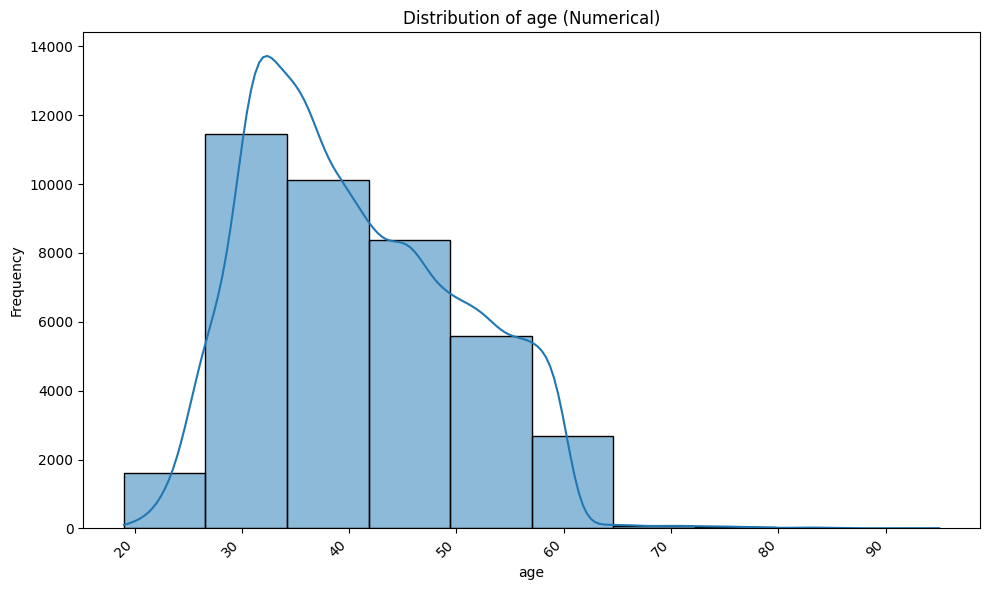

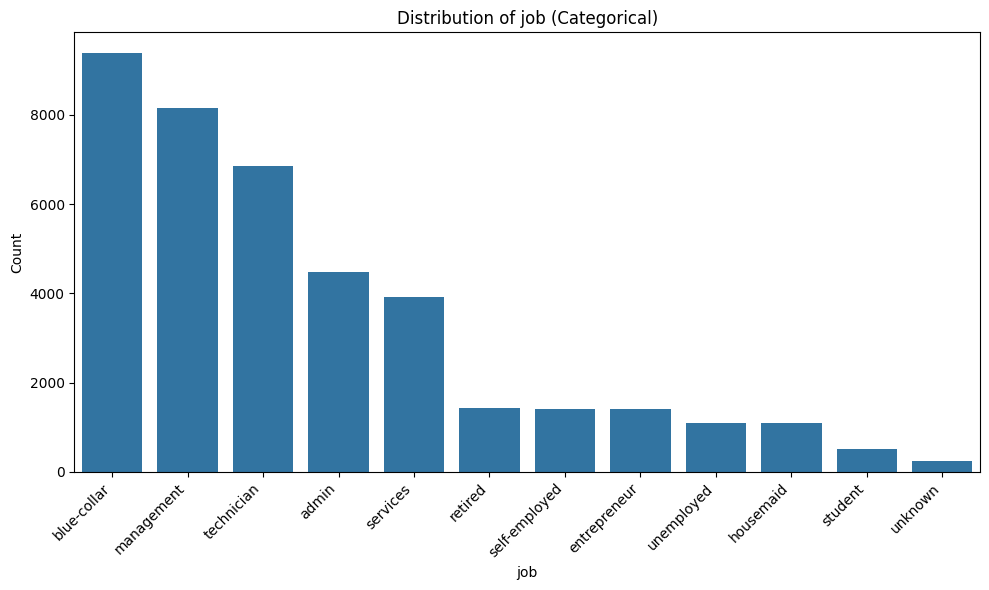

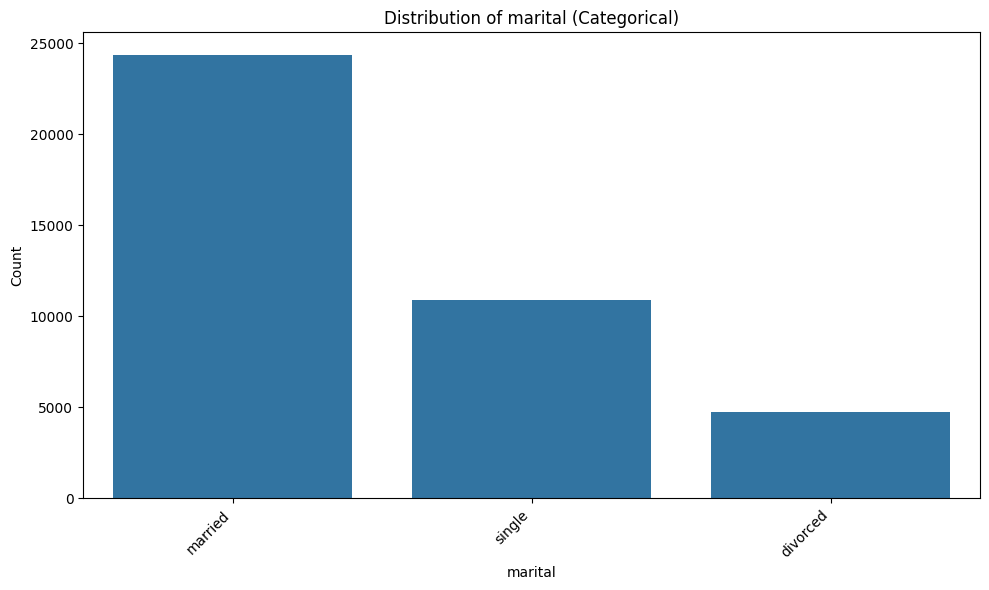

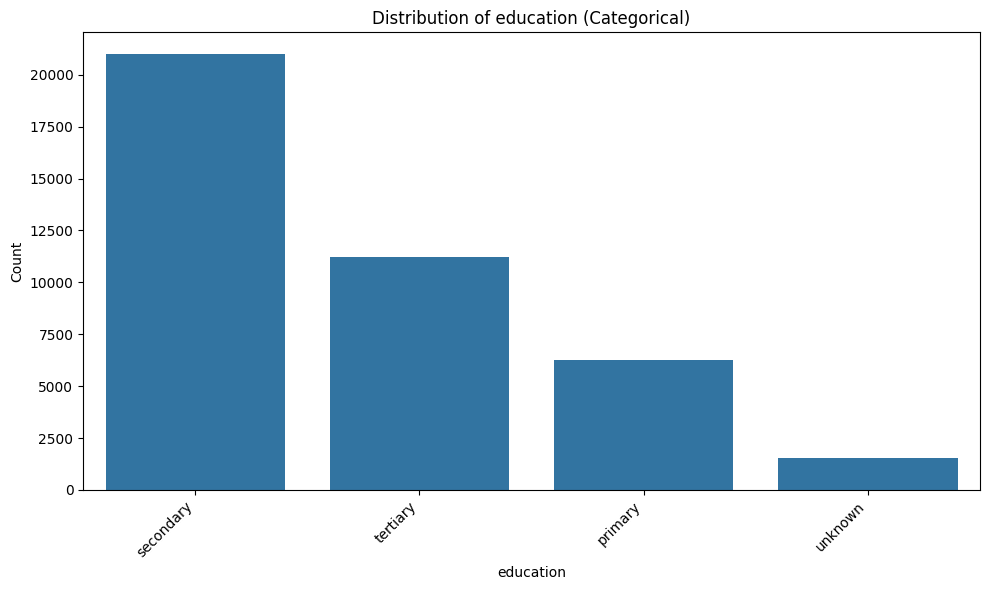

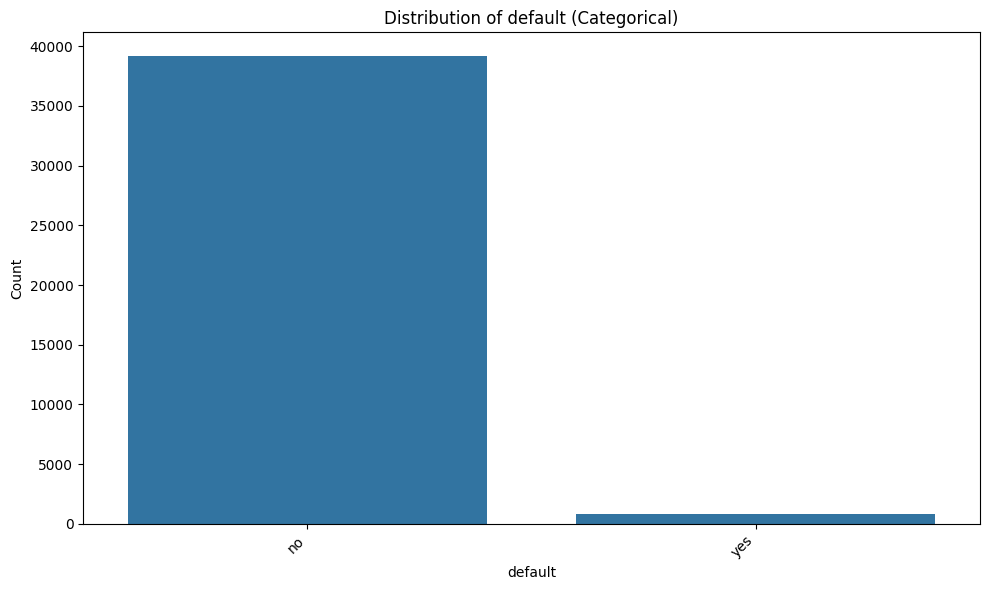

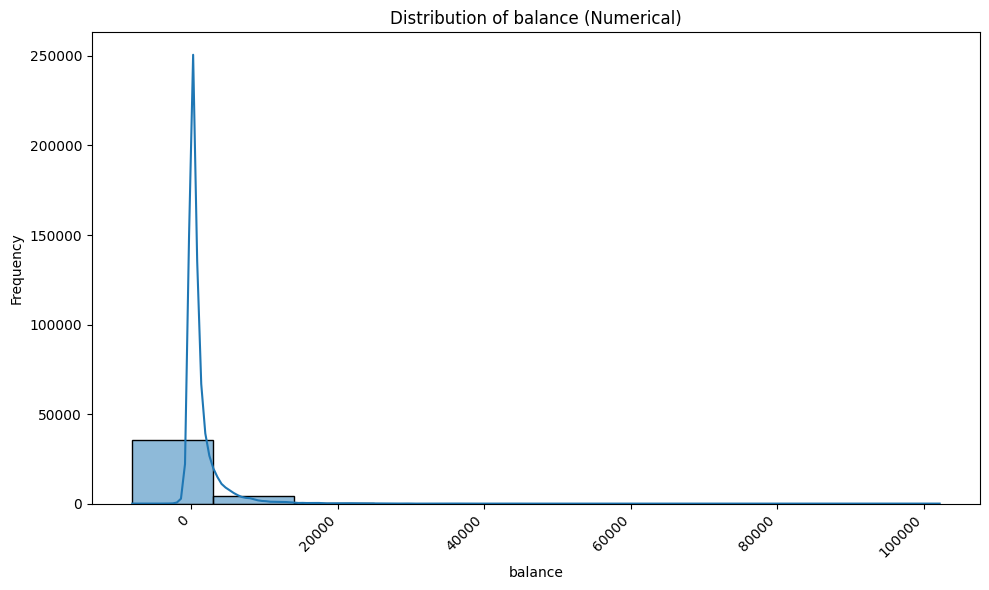

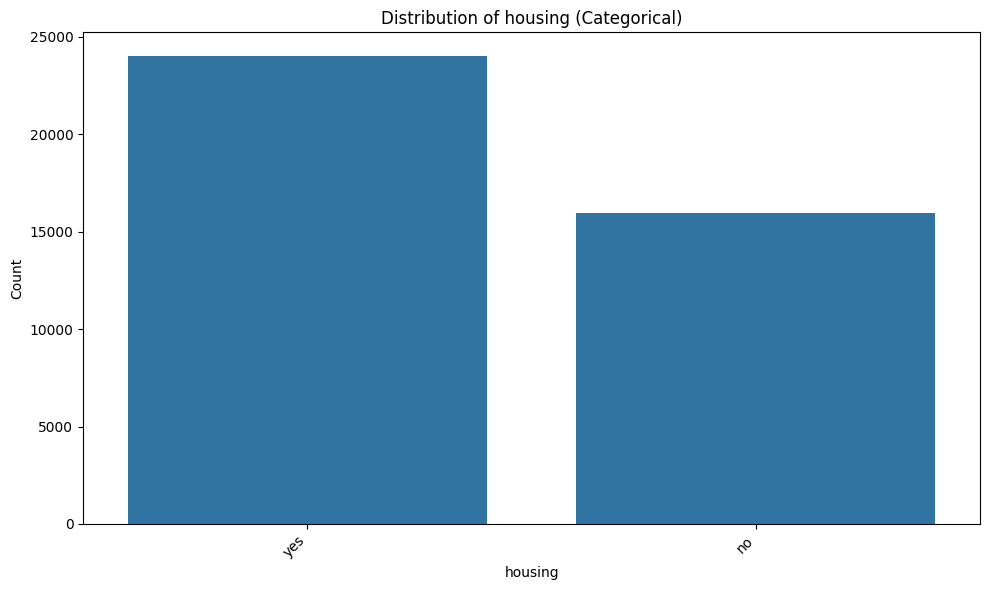

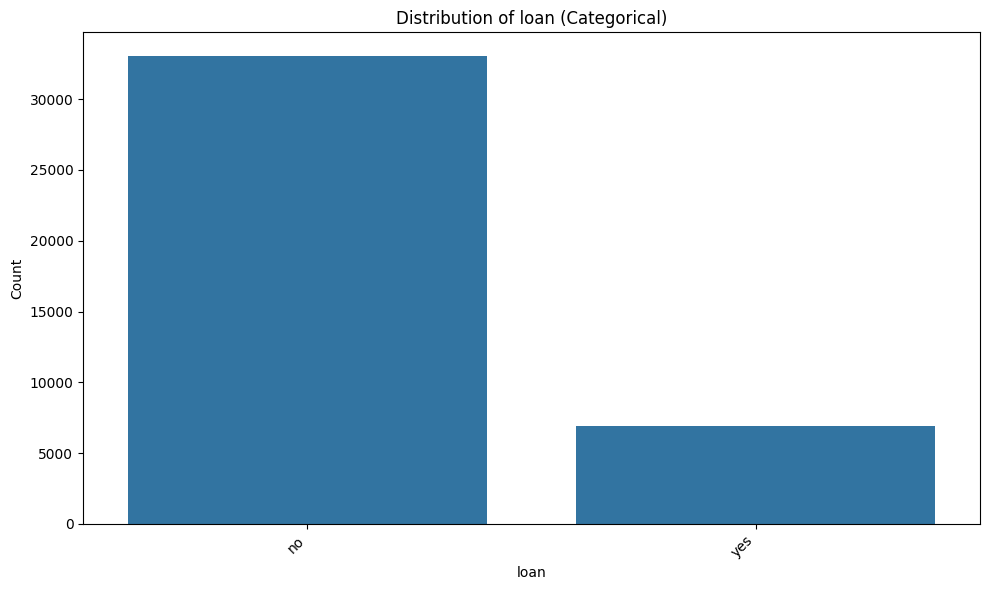

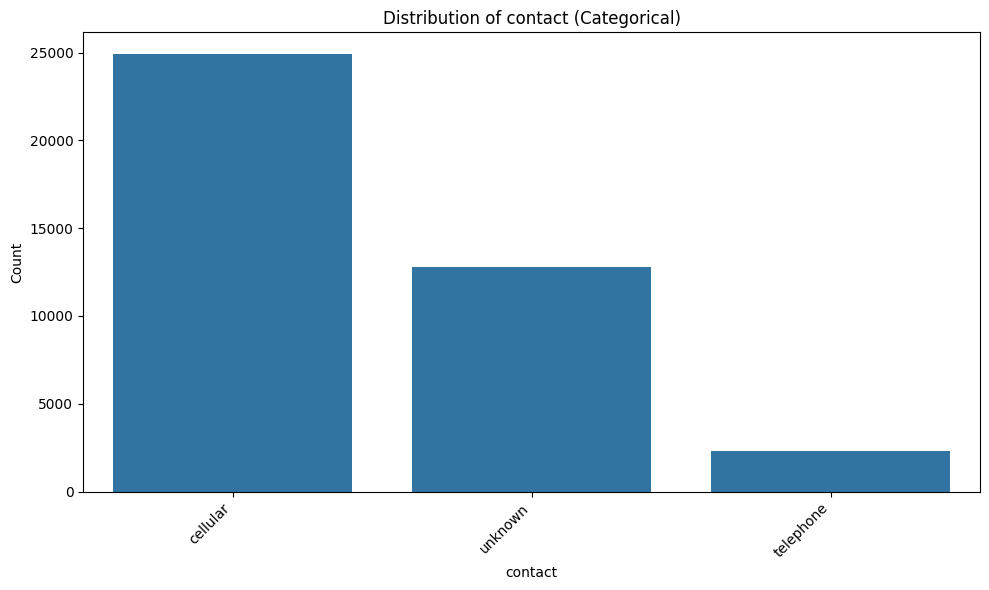

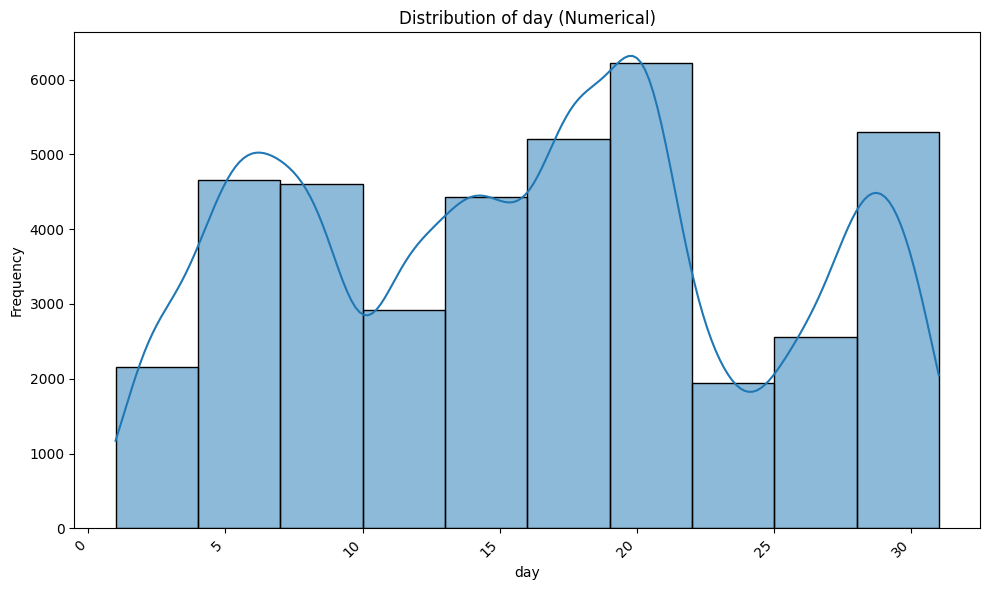

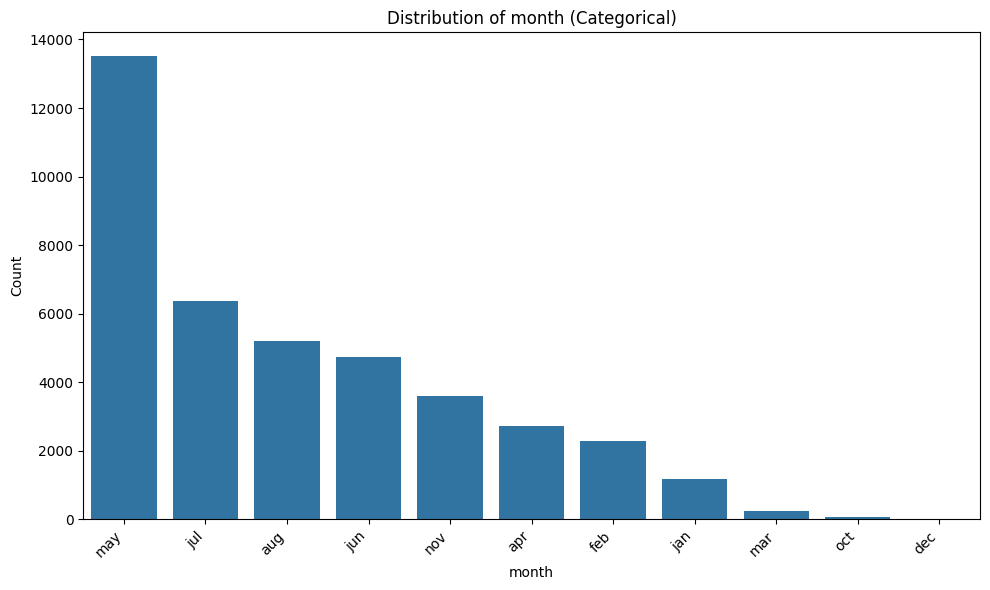

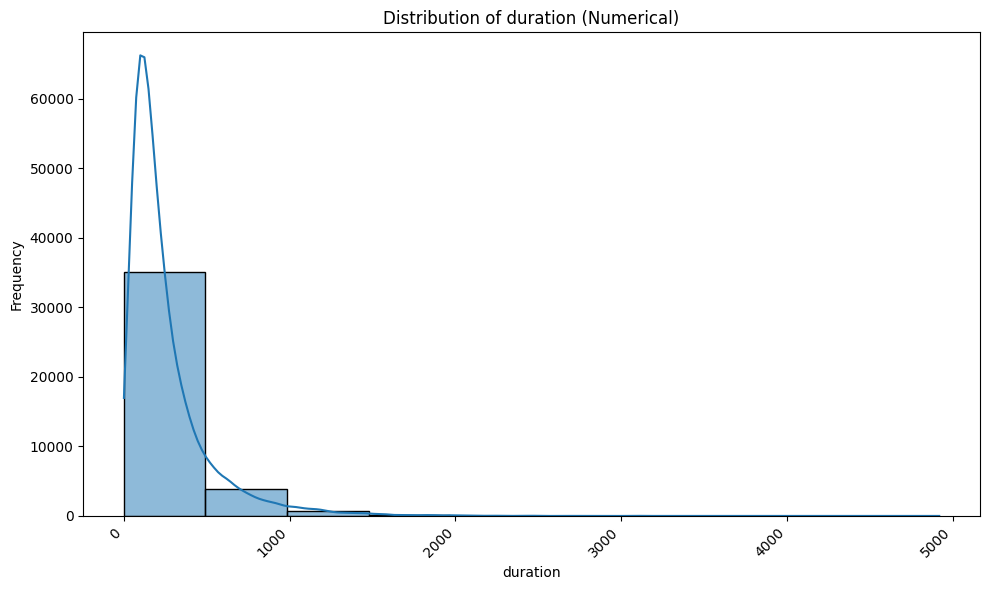

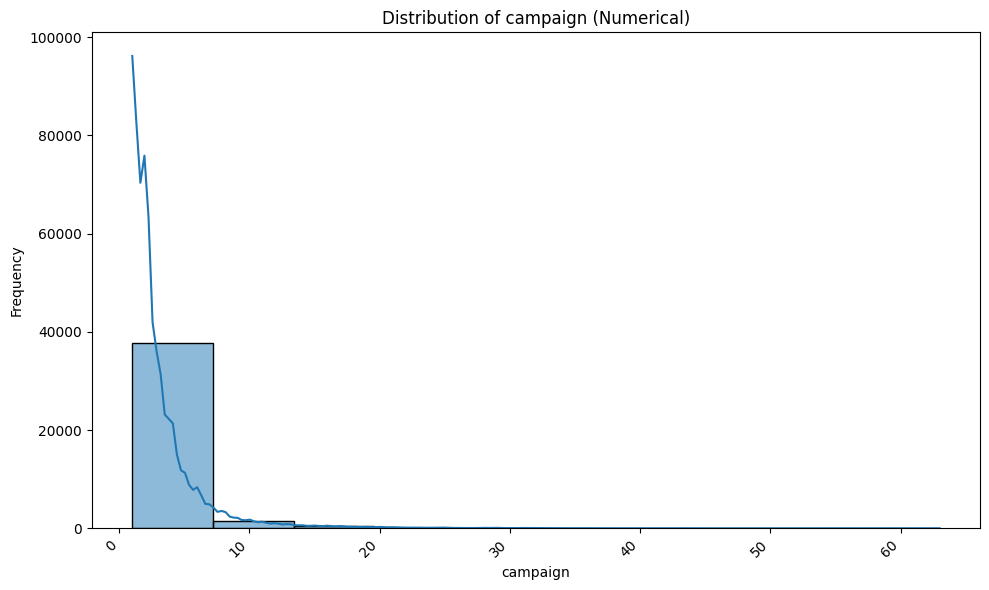

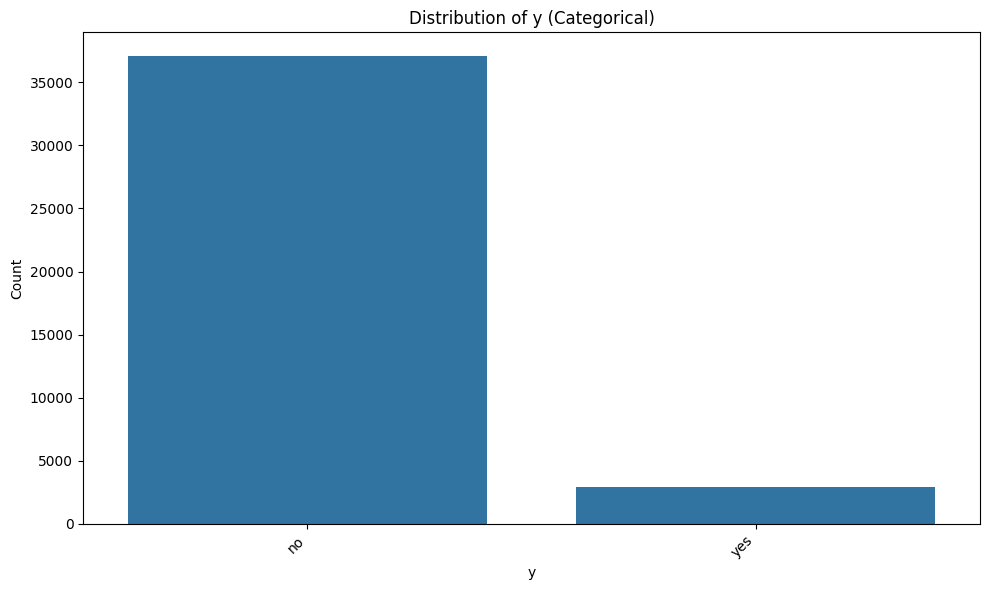

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.columns:
    plt.figure(figsize=(10, 6))
    if df[col].dtype == 'object':  # Categorical column
        sns.countplot(data=df, x=col, order=df[col].value_counts().index)
        plt.title(f'Distribution of {col} (Categorical)')
        plt.xlabel(col)
        plt.ylabel('Count')
    else:  # Numerical column
        sns.histplot(data=df, x=col, kde=True, bins = 10) # kde=True adds a kernel density estimate
        plt.title(f'Distribution of {col} (Numerical)')
        plt.xlabel(col)
        plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Business impact: the company is spending a lot of time and employee resources to make campaign calls to the customers

Visualizing numerical columns with adjusted x-axis limits to remove long trailing ends:
  Column 'age': x-axis adjusted from 24.00 to 60.00


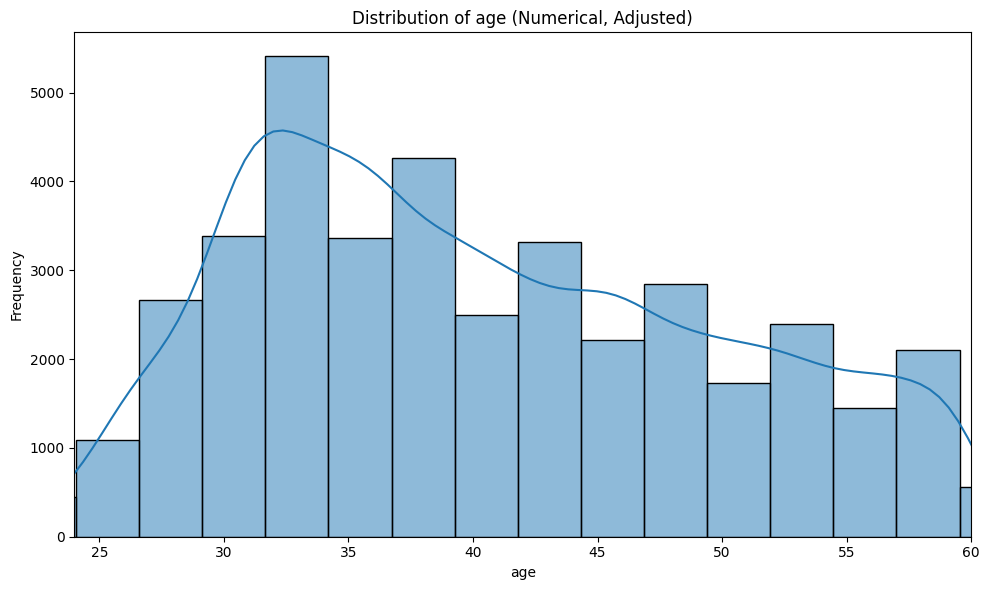

  Column 'balance': x-axis adjusted from -672.01 to 12857.20


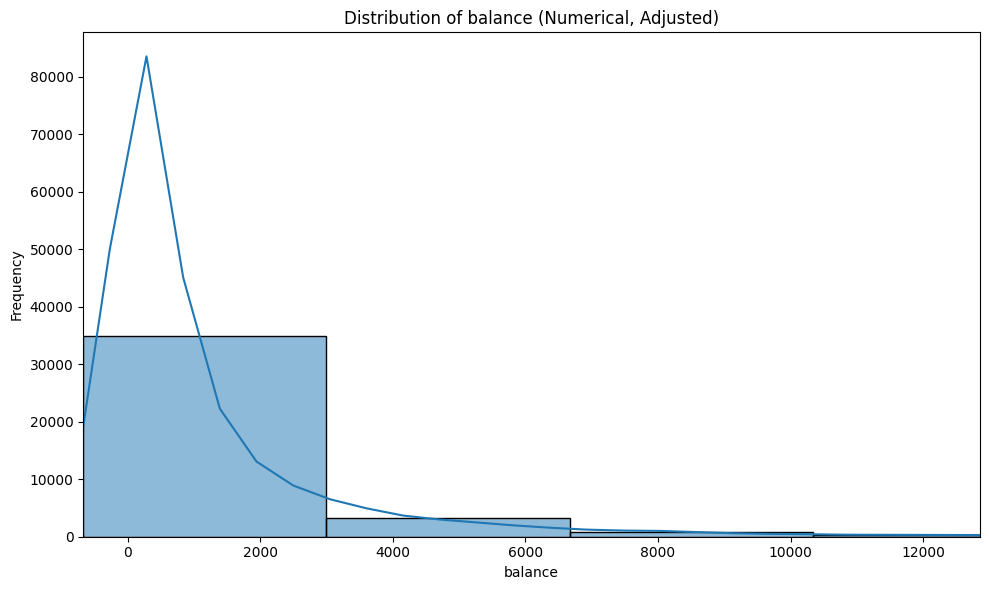

  Column 'day': x-axis adjusted from 2.00 to 31.00


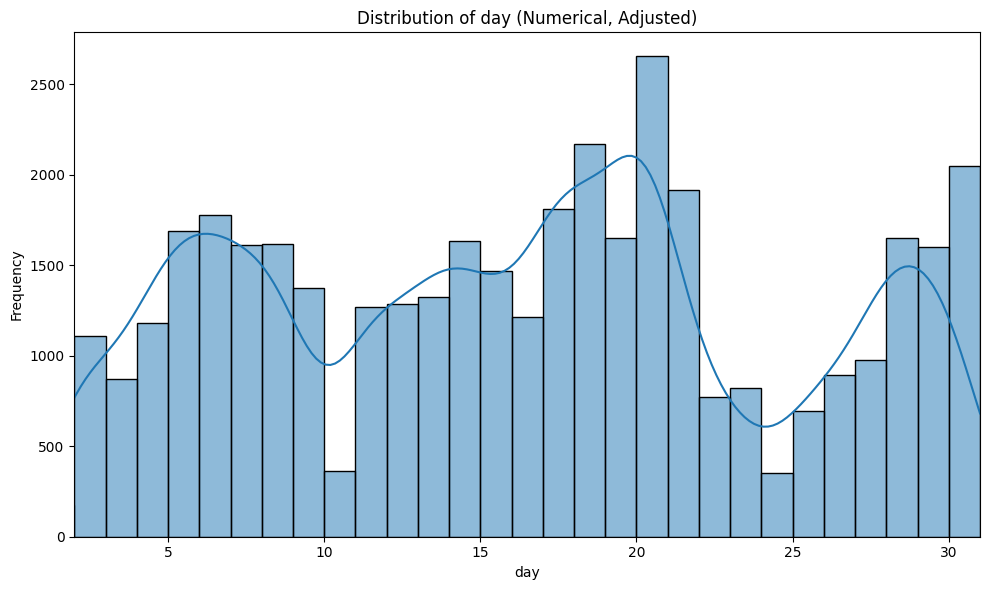

  Column 'duration': x-axis adjusted from 11.00 to 1273.02


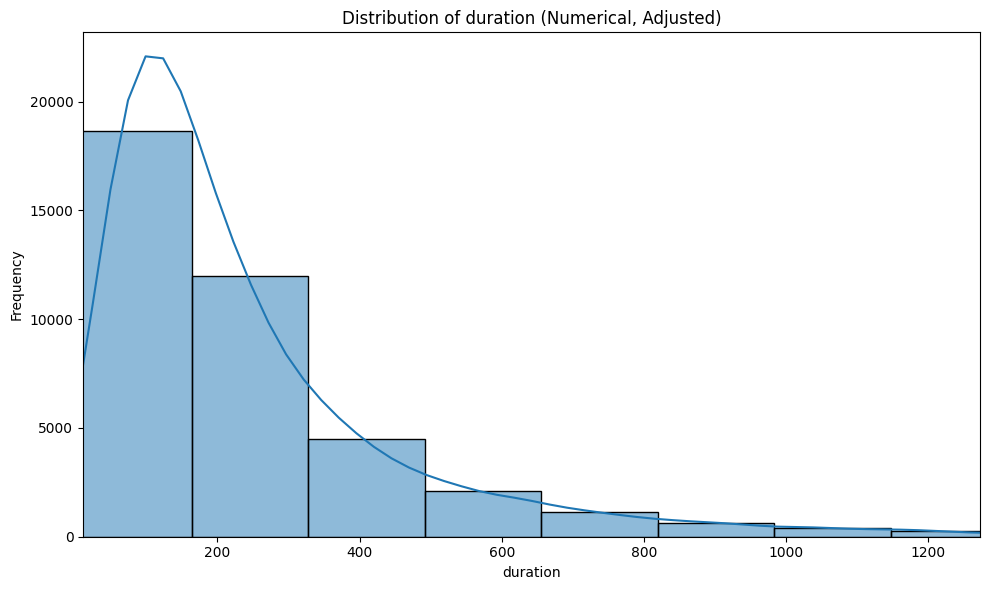

  Column 'campaign': x-axis adjusted from 1.00 to 17.00


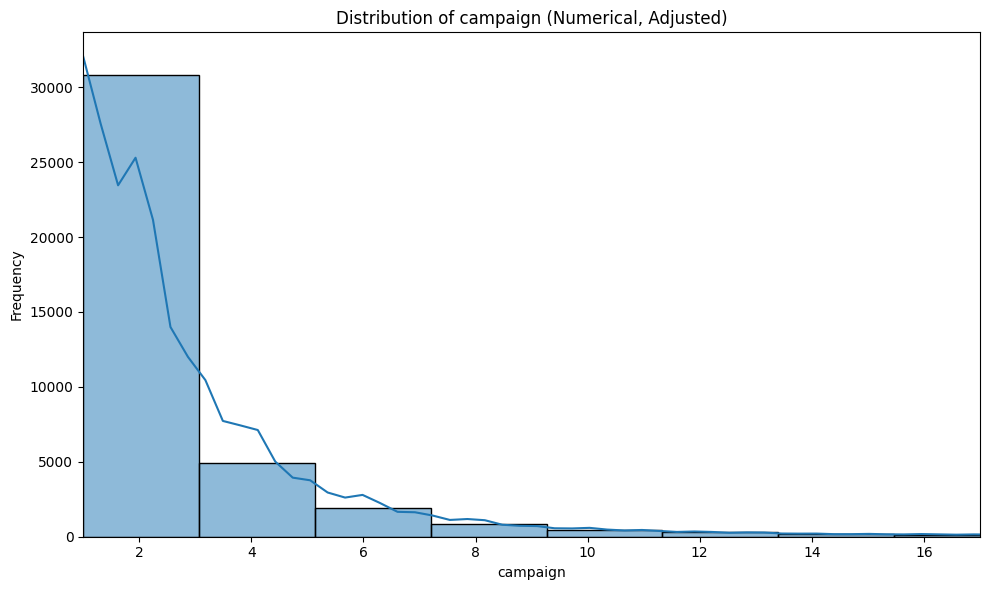


Note: The x-axis limits for numerical columns have been adjusted using the 1st and 99th percentiles to focus on the main distribution and remove extreme outliers. This means values outside this range are not shown on the plot.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identify numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

print("Visualizing numerical columns with adjusted x-axis limits to remove long trailing ends:")

for col in numerical_cols:
    plt.figure(figsize=(10, 6))

    # Calculate lower and upper bounds using percentiles
    # This helps to clip extreme values that create long tails
    lower_bound = df[col].quantile(0.01) # 1st percentile
    upper_bound = df[col].quantile(0.99) # 99th percentile

    sns.histplot(data=df, x=col, kde=True, bins=30) # Using 30 bins for reasonable granularity
    plt.title(f'Distribution of {col} (Numerical, Adjusted)')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Apply x-axis limits to remove long trailing ends
    plt.xlim(lower_bound, upper_bound)
    print(f"  Column '{col}': x-axis adjusted from {lower_bound:.2f} to {upper_bound:.2f}")

    plt.tight_layout()
    plt.show()

print("\nNote: The x-axis limits for numerical columns have been adjusted using the 1st and 99th percentiles to focus on the main distribution and remove extreme outliers. This means values outside this range are not shown on the plot.")

Generating violin plots for numerical columns:


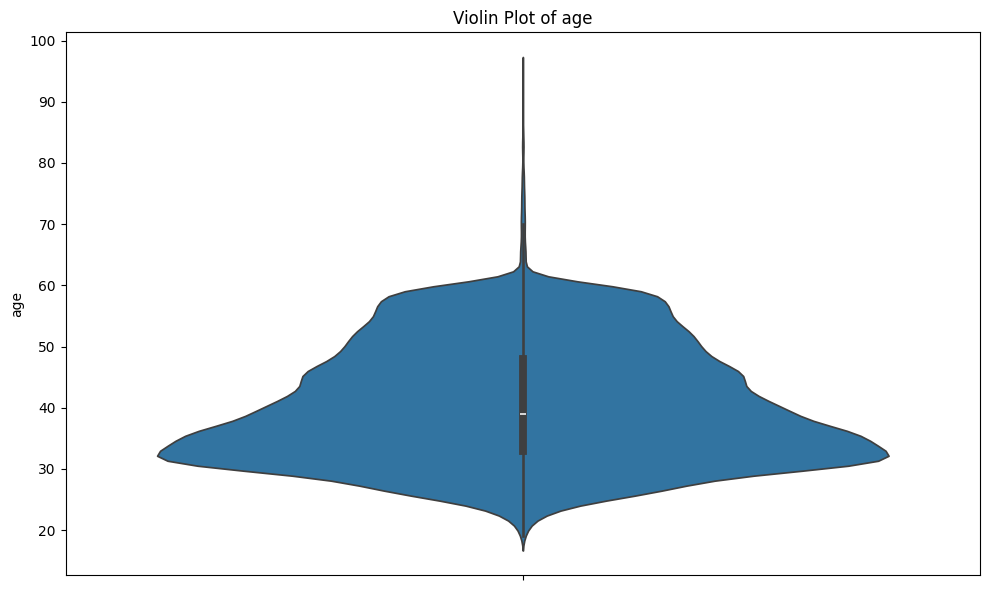

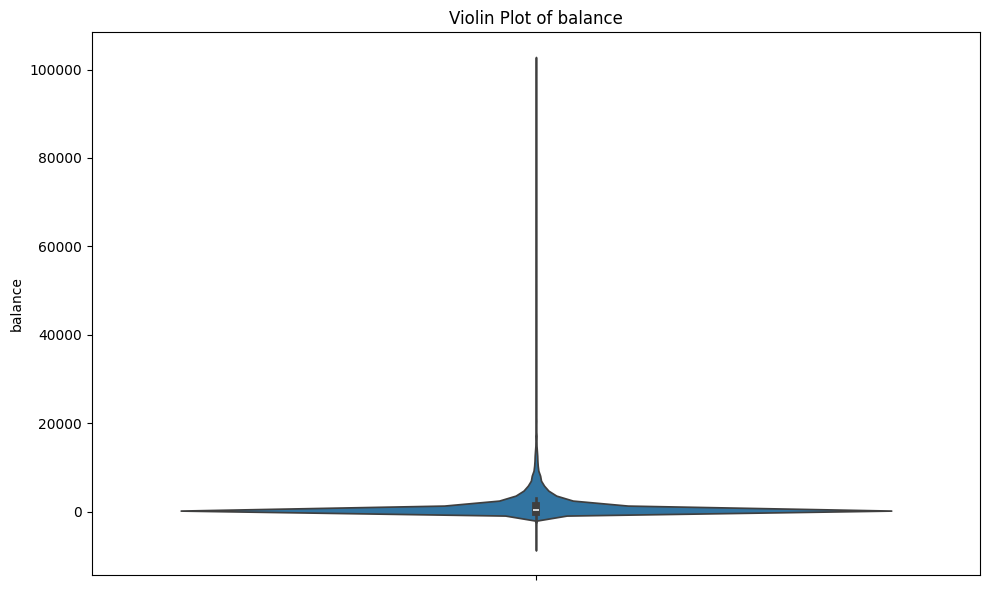

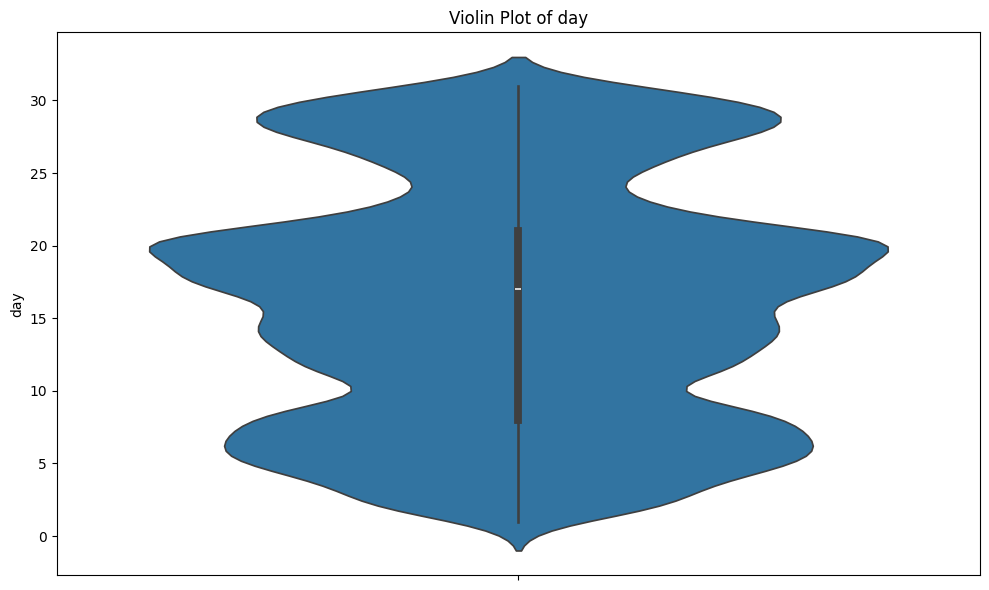

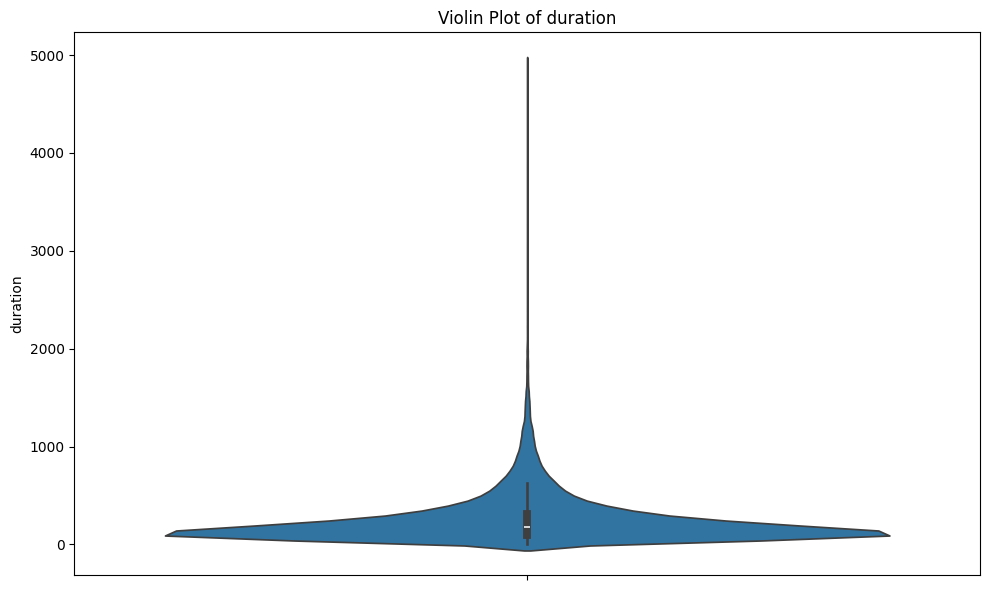

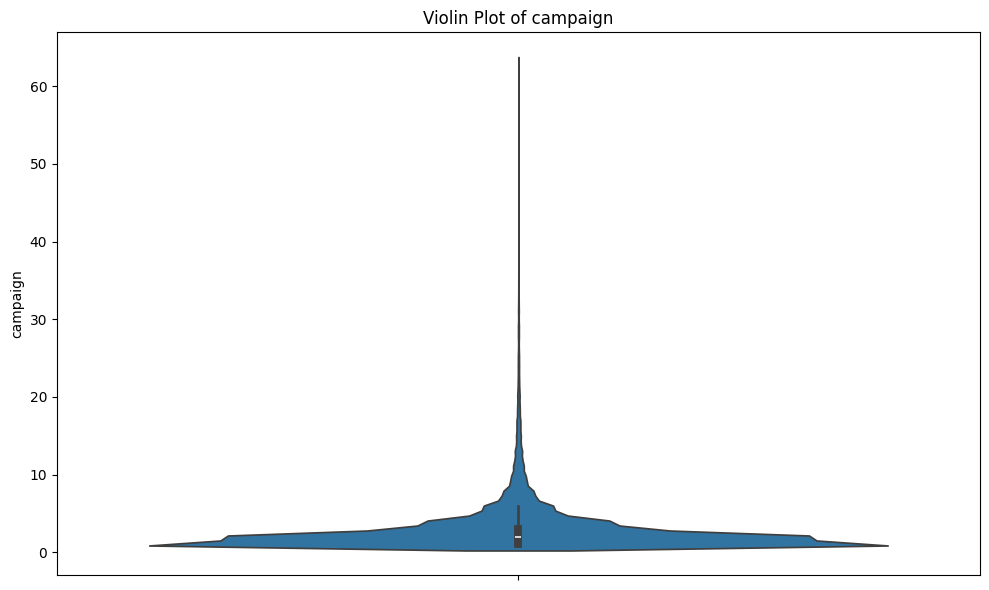

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

numerical_cols = df.select_dtypes(include=np.number).columns

print("Generating violin plots for numerical columns:")

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.violinplot(y=df[col])
    plt.title(f'Violin Plot of {col}')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Generating violin plots for selected columns, with log transformation where appropriate:
  'age' column transformed using log(1+x).


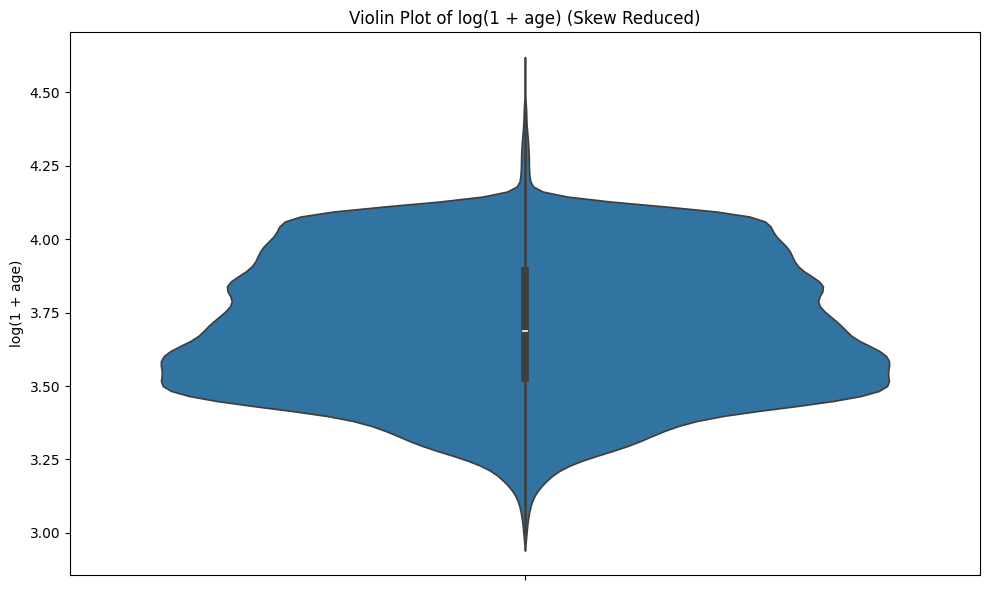

  'balance' column transformed using signed_log1p. Plotting positive and negative balances separately.


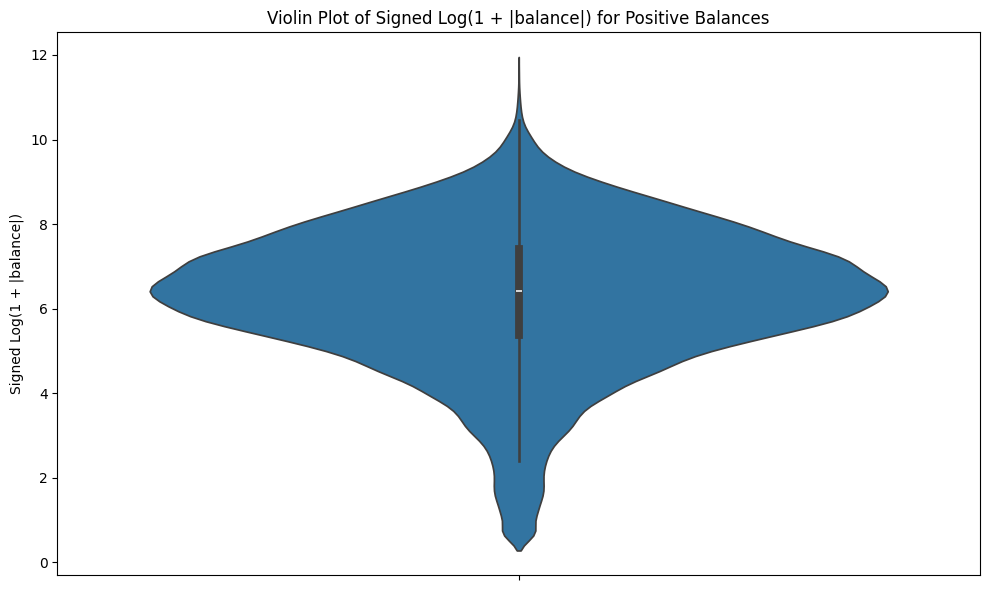

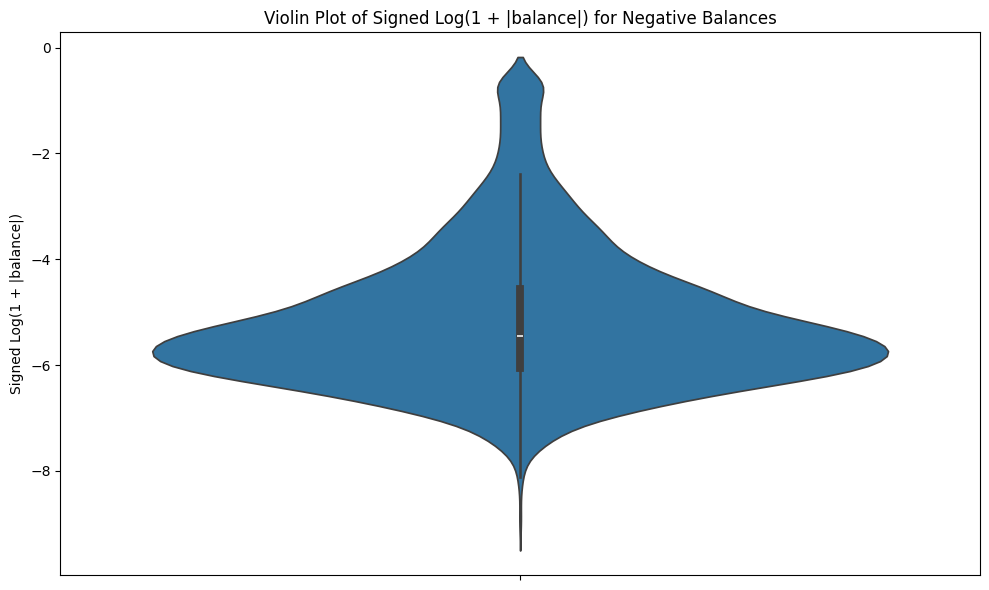

  'duration' column transformed using log(1+x).


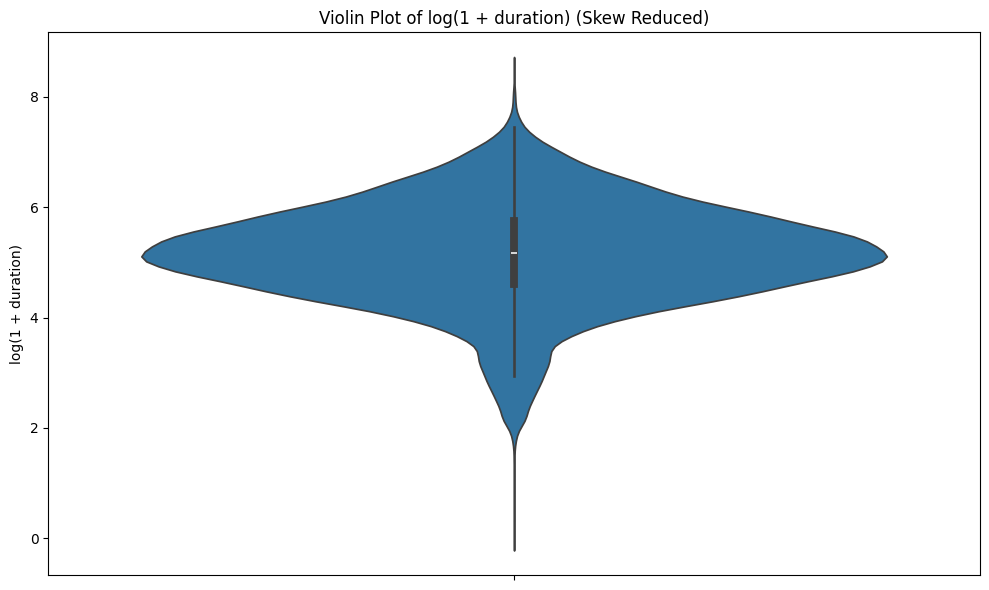

  'campaign' column transformed using log(1+x).


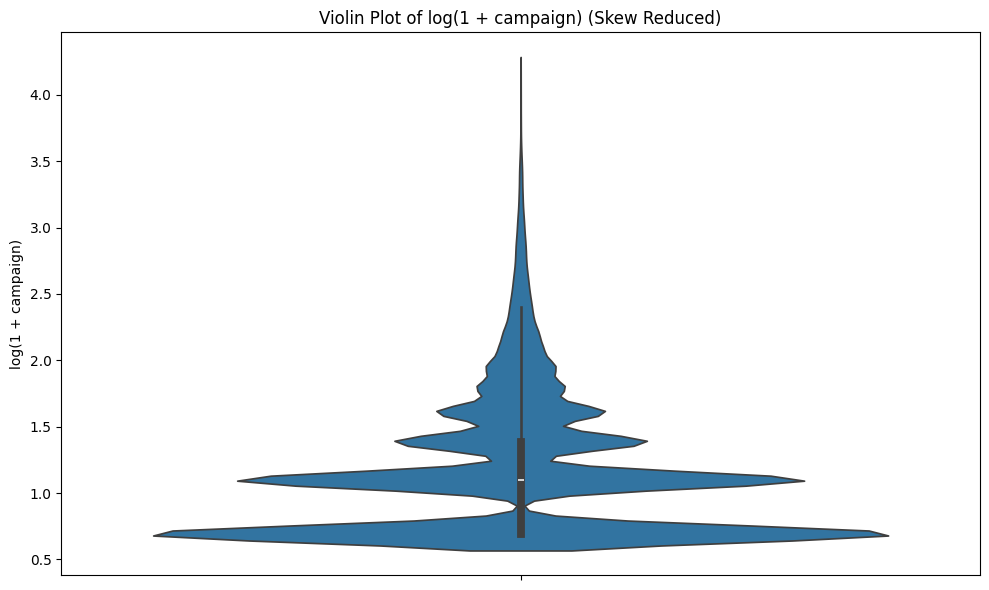

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Columns to visualize
selected_cols = ['age', 'balance', 'duration', 'campaign']

# Create a temporary DataFrame for transformations
df_temp = df[selected_cols].copy()

# Define a signed log transformation function
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

print("Generating violin plots for selected columns, with log transformation where appropriate:")

for col in selected_cols:
    if col == 'balance':
        # Apply signed log transformation to balance
        df_temp['signed_log_balance'] = signed_log1p(df_temp['balance'])

        # Separate positive and negative transformed balances
        positive_transformed_balance = df_temp[df_temp['balance'] > 0]['signed_log_balance']
        negative_transformed_balance = df_temp[df_temp['balance'] < 0]['signed_log_balance']

        print(f"  '{col}' column transformed using signed_log1p. Plotting positive and negative balances separately.")

        if not positive_transformed_balance.empty:
            plt.figure(figsize=(10, 6))
            sns.violinplot(y=positive_transformed_balance)
            plt.title(f'Violin Plot of Signed Log(1 + |{col}|) for Positive Balances')
            plt.ylabel(f'Signed Log(1 + |{col}|)')
            plt.tight_layout()
            plt.show()
        else:
            print(f"  No positive '{col}' values to plot after transformation.")

        if not negative_transformed_balance.empty:
            plt.figure(figsize=(10, 6))
            sns.violinplot(y=negative_transformed_balance)
            plt.title(f'Violin Plot of Signed Log(1 + |{col}|) for Negative Balances')
            plt.ylabel(f'Signed Log(1 + |{col}|)')
            plt.tight_layout()
            plt.show()
        else:
            print(f"  No negative '{col}' values to plot after transformation.")

    elif col in ['age', 'duration', 'campaign']:
        # Apply log(1+x) transformation for positively skewed, non-negative data
        df_temp[f'log_{col}'] = np.log1p(df_temp[col])
        plt.figure(figsize=(10, 6))
        sns.violinplot(y=df_temp[f'log_{col}'])
        plt.title(f'Violin Plot of log(1 + {col}) (Skew Reduced)')
        plt.ylabel(f'log(1 + {col})')
        print(f"  '{col}' column transformed using log(1+x).")
        plt.tight_layout()
        plt.show()


# Bivariate Analysis

In [ ]:
for y_val in df['y'].unique():
    print(f"\n--- Analysis for y = '{y_val}' ---")
    df_subset = df[df['y'] == y_val]
    for col in df_subset.columns:
        if col == 'y':  # Skip the target variable itself
            continue
        print(f"Column: {col}")
        if df_subset[col].dtype in ['int64', 'float64']:
            print(f"  Minimum value: {df_subset[col].min()}")
            print(f"  Maximum value: {df_subset[col].max()}")
            print(f"  Mean value: {df_subset[col].mean():.2f}")
            print(f"  Median value: {df_subset[col].median()}")
        else:
            print("  Value Counts:")
            print(df_subset[col].value_counts())
            print("  Percentages:")
            print((df_subset[col].value_counts(normalize=True) * 100).round(2))
        print("\n")


--- Analysis for y = 'no' ---
Column: age
  Minimum value: 19
  Maximum value: 94
  Mean value: 40.60
  Median value: 39.0


Column: job
  Value Counts:
job
blue-collar      8848
management       7490
technician       6355
admin            4132
services         3672
entrepreneur     1317
self-employed    1302
retired          1286
housemaid        1034
unemployed       1008
student           442
unknown           218
Name: count, dtype: int64
  Percentages:
job
blue-collar      23.85
management       20.19
technician       17.13
admin            11.14
services          9.90
entrepreneur      3.55
self-employed     3.51
retired           3.47
housemaid         2.79
unemployed        2.72
student           1.19
unknown           0.59
Name: proportion, dtype: float64


Column: marital
  Value Counts:
marital
married     22908
single       9862
divorced     4334
Name: count, dtype: int64
  Percentages:
marital
married     61.74
single      26.58
divorced    11.68
Name: proportion, dtype: 

Generating grouped bar plots for categorical features vs. 'y' target variable (showing percentages):


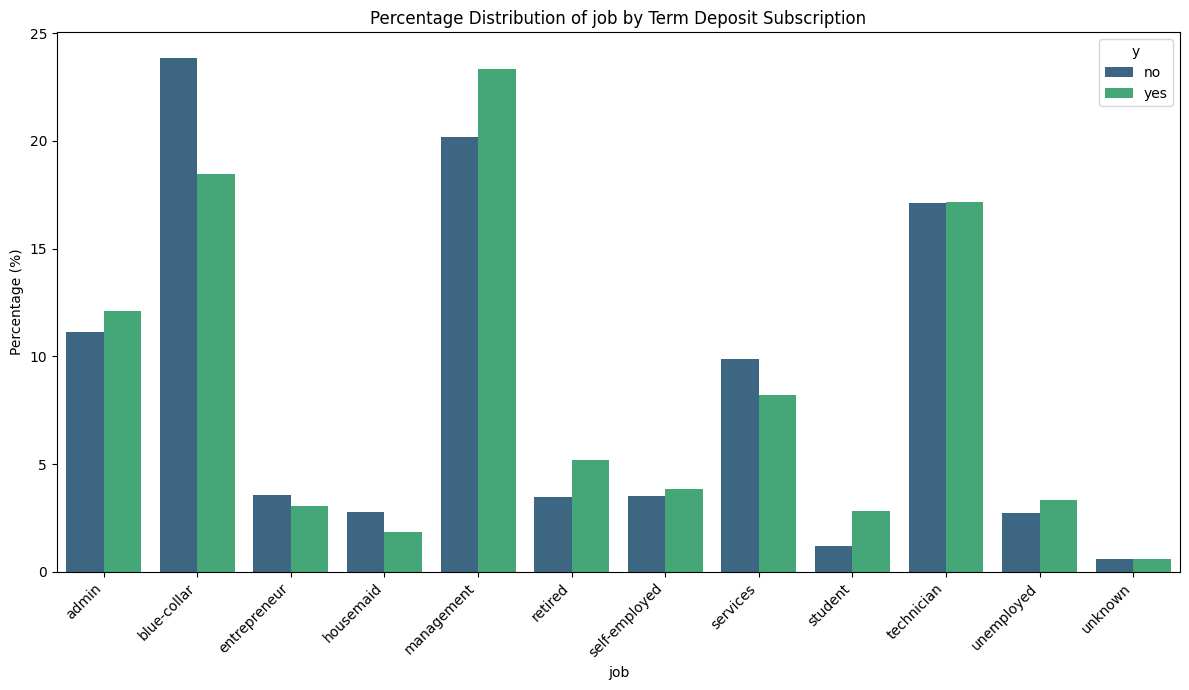

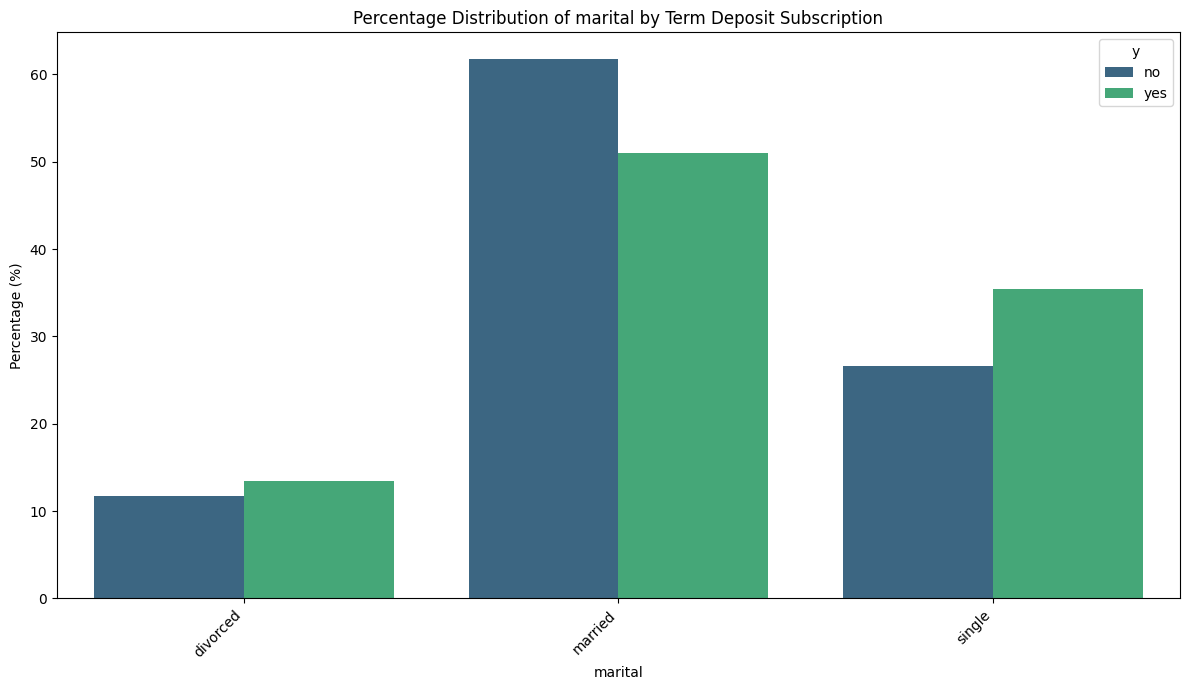

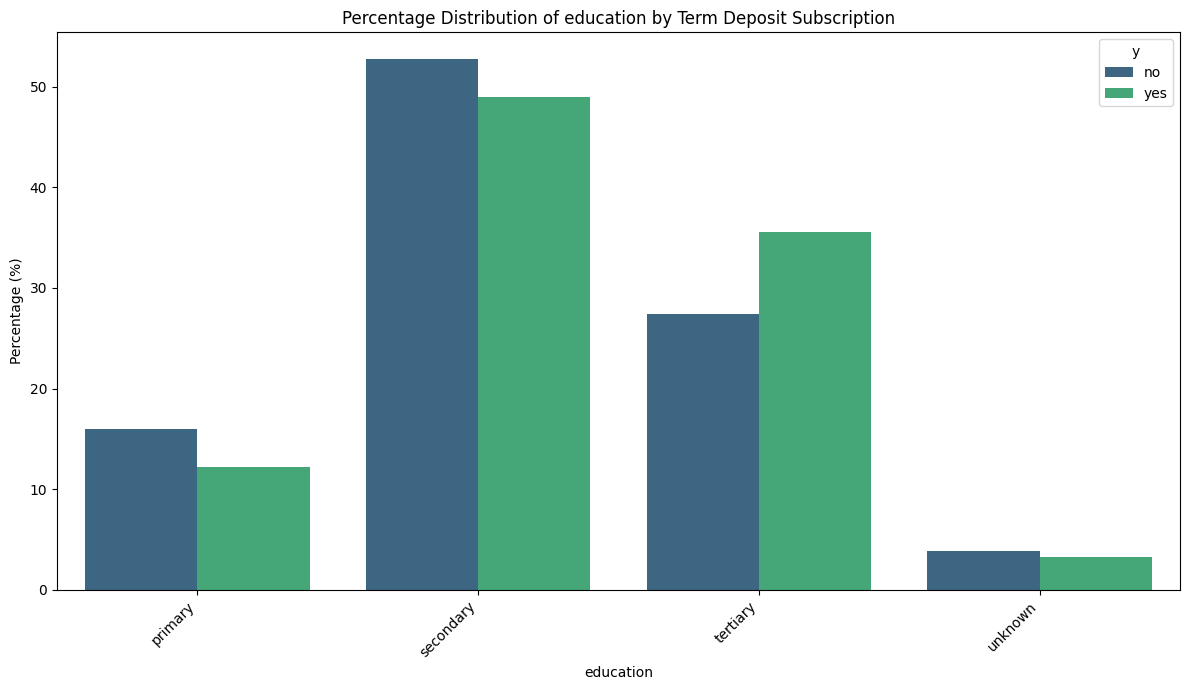

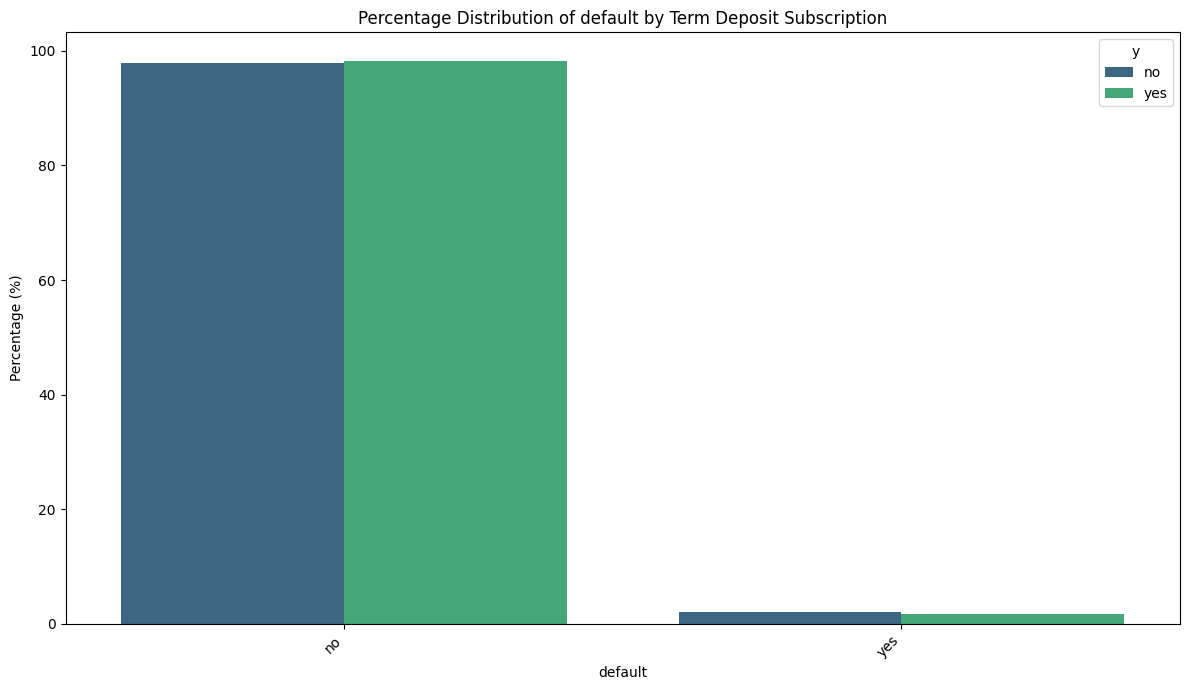

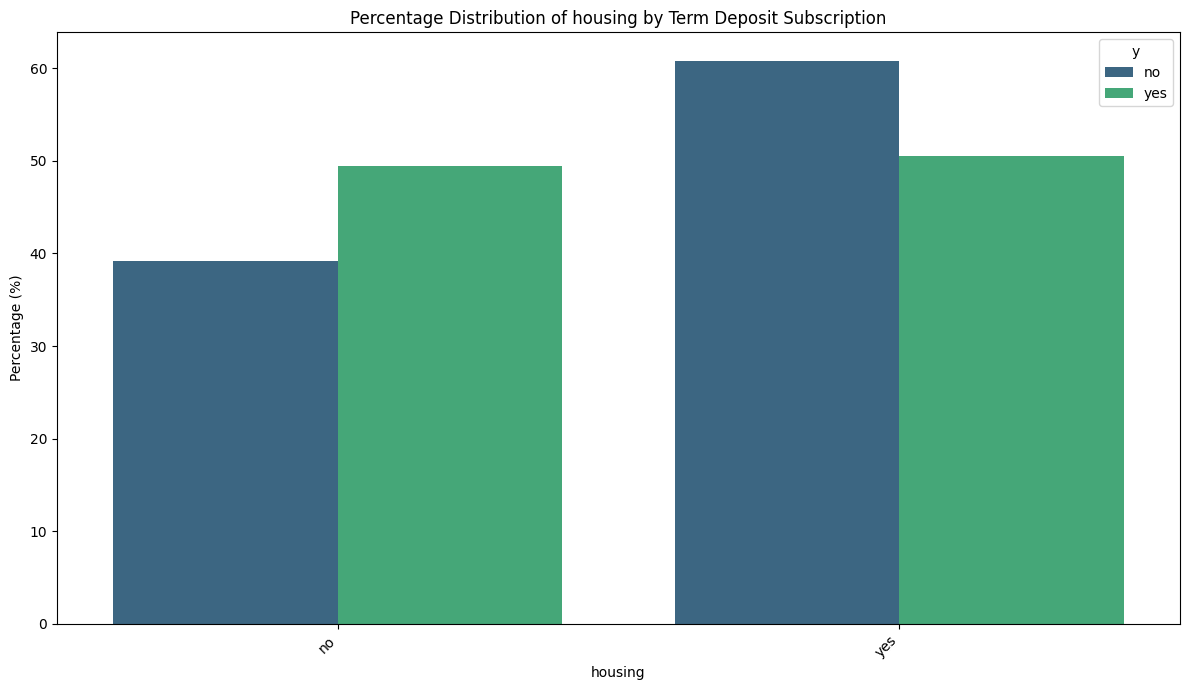

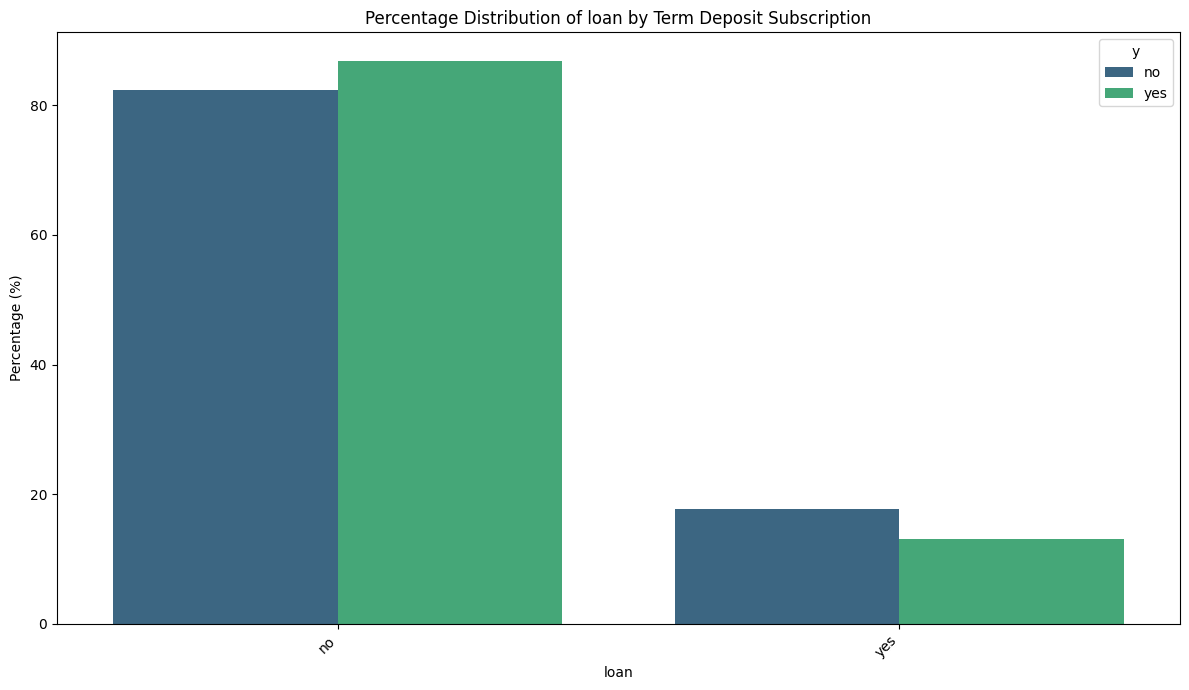

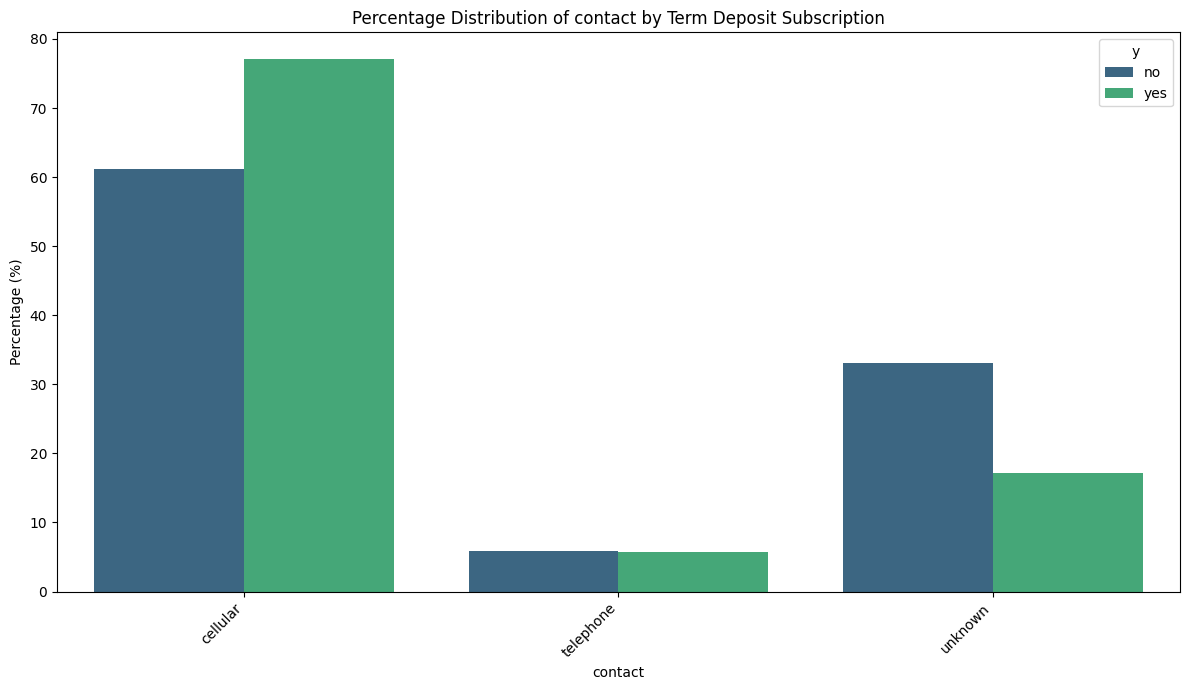

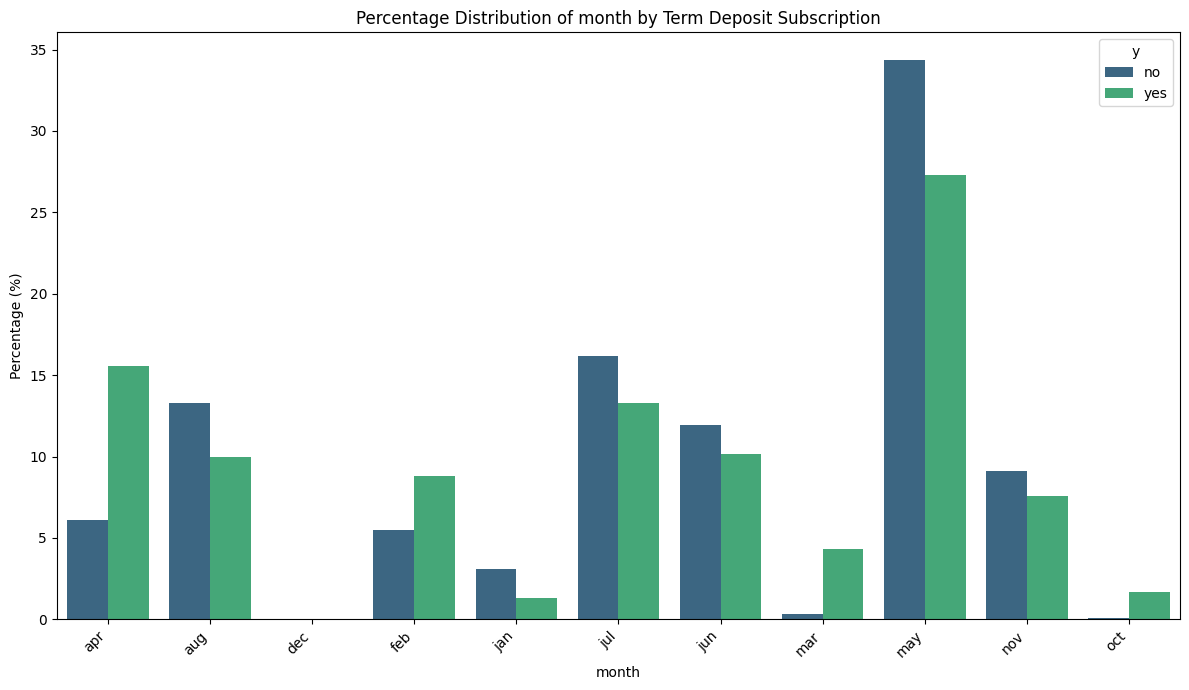

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Identify categorical columns, excluding the target variable 'y'
categorical_cols = df.select_dtypes(include='object').columns.drop('y', errors='ignore')

print("Generating grouped bar plots for categorical features vs. 'y' target variable (showing percentages):")

for col in categorical_cols:
    # Calculate percentages within each 'y' category
    # normalize='columns' calculates percentage relative to the sum of each column (y='no' vs y='yes')
    percentage_df = pd.crosstab(df[col], df['y'], normalize='columns') * 100

    # Melt the DataFrame for easier plotting with seaborn.barplot
    percentage_df_melted = percentage_df.reset_index().melt(id_vars=col, var_name='y', value_name='percentage')

    plt.figure(figsize=(12, 7))
    sns.barplot(data=percentage_df_melted, x=col, y='percentage', hue='y', palette='viridis')
    plt.title(f'Percentage Distribution of {col} by Term Deposit Subscription')
    plt.xlabel(col)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Generating percentage distribution bar plots for binned numerical features vs. 'y' target variable:


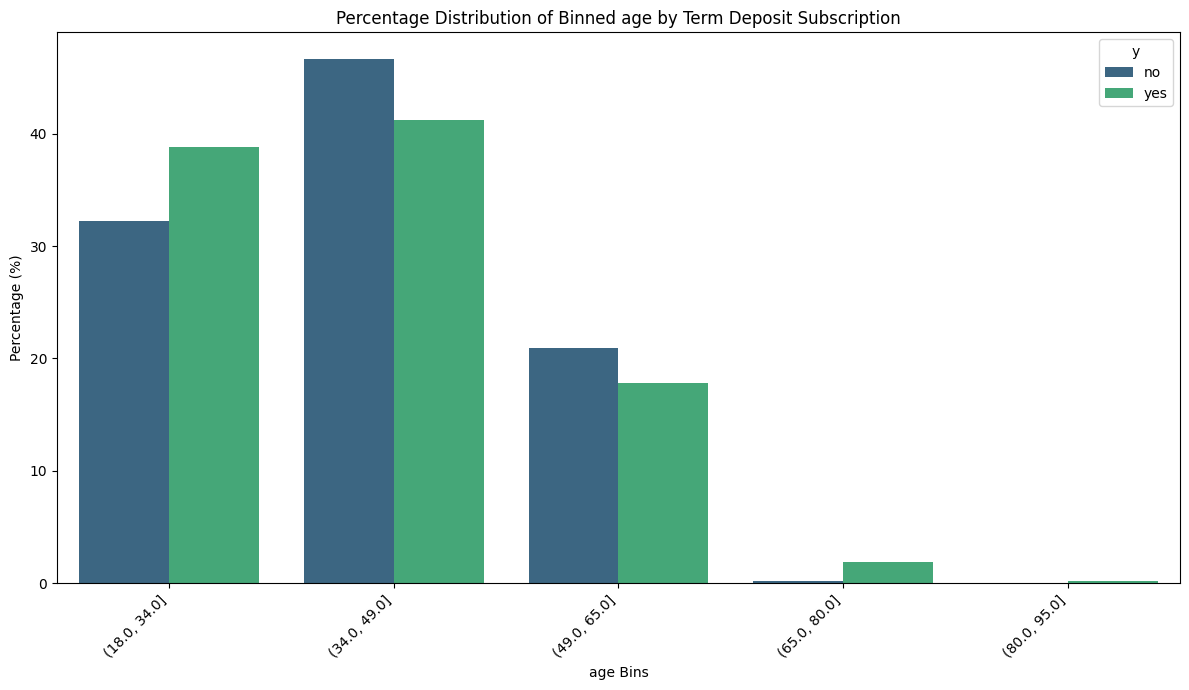

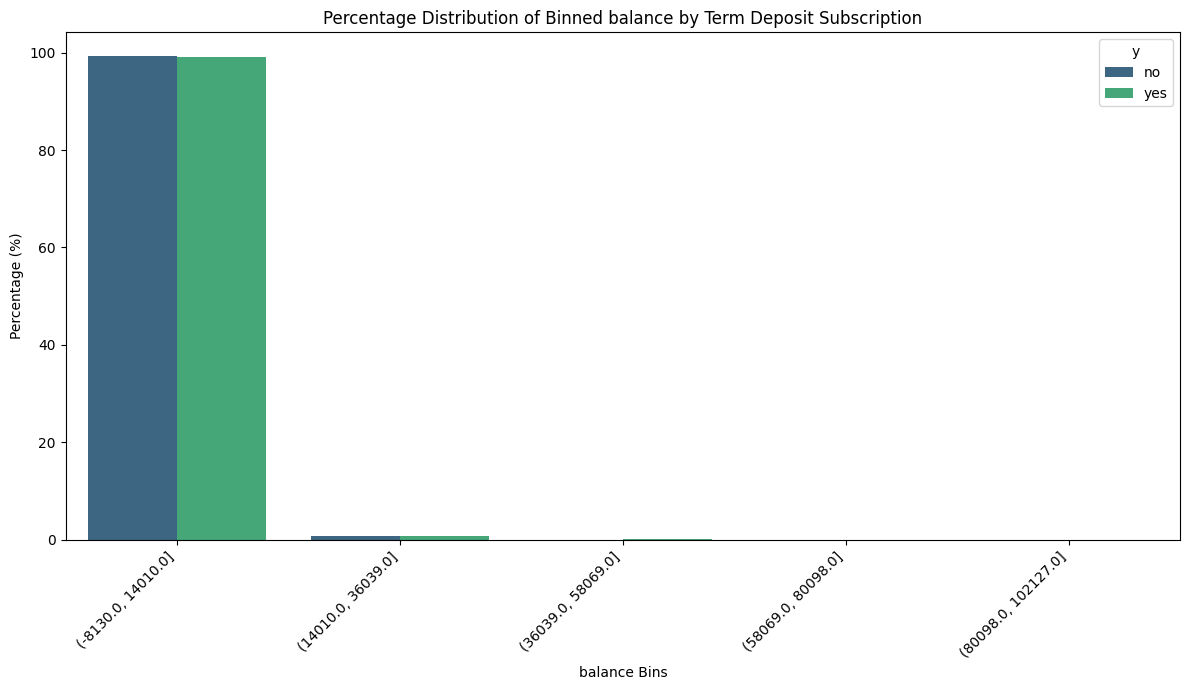

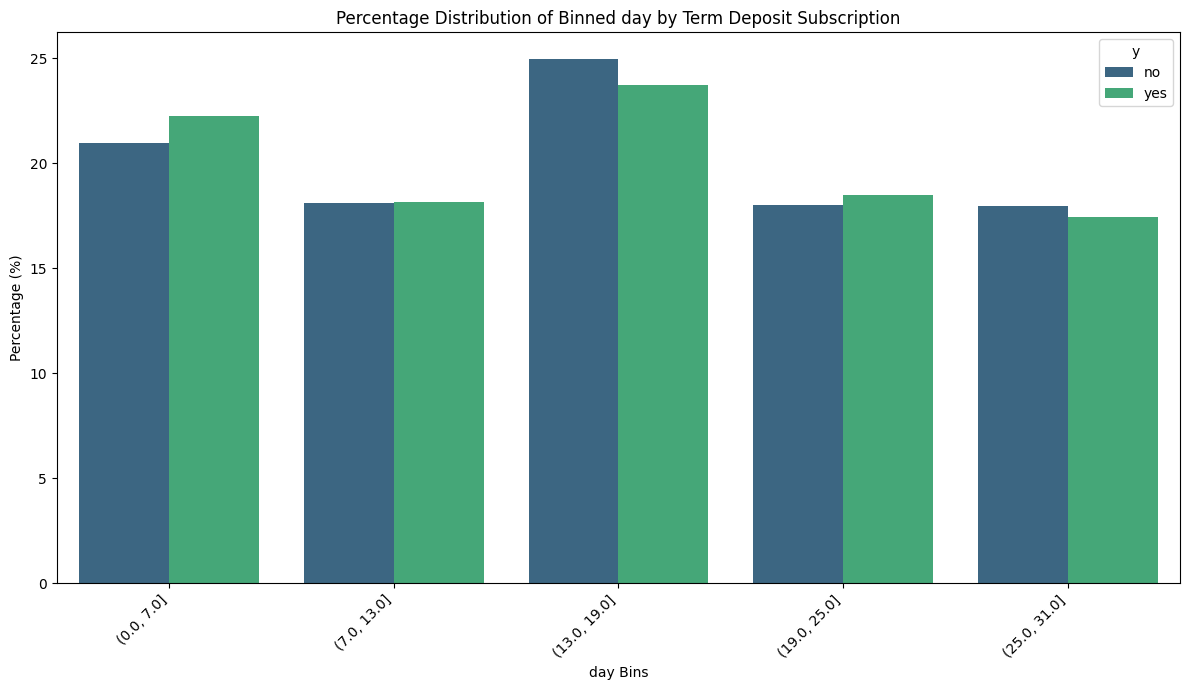

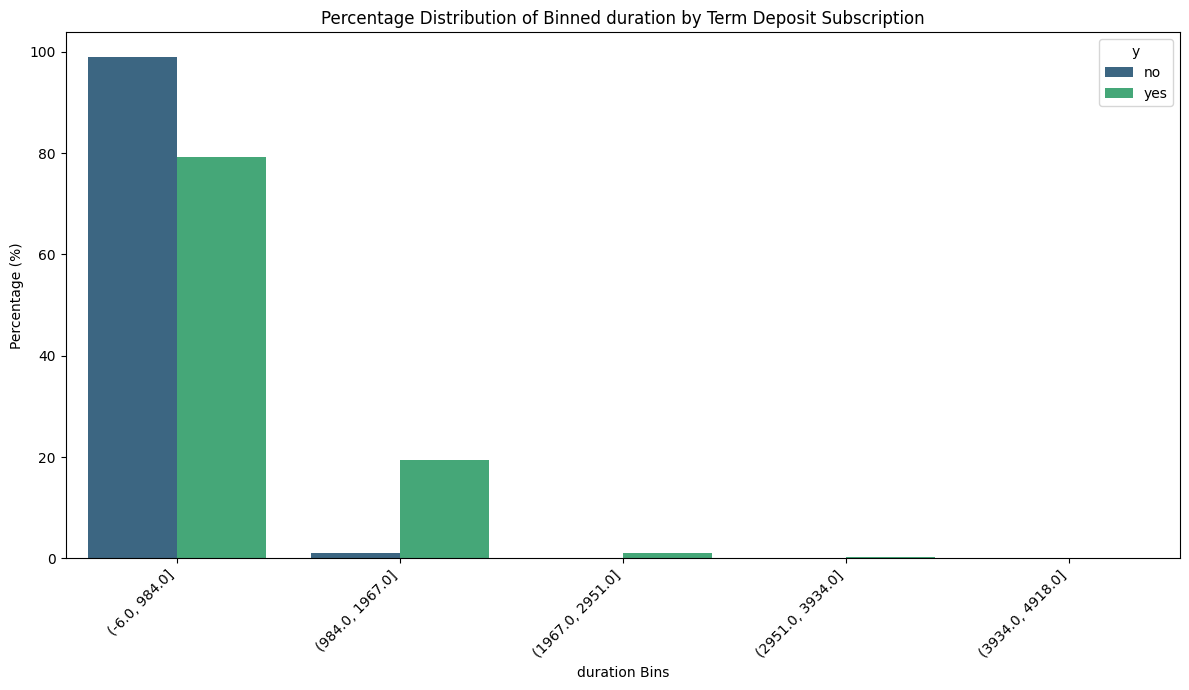

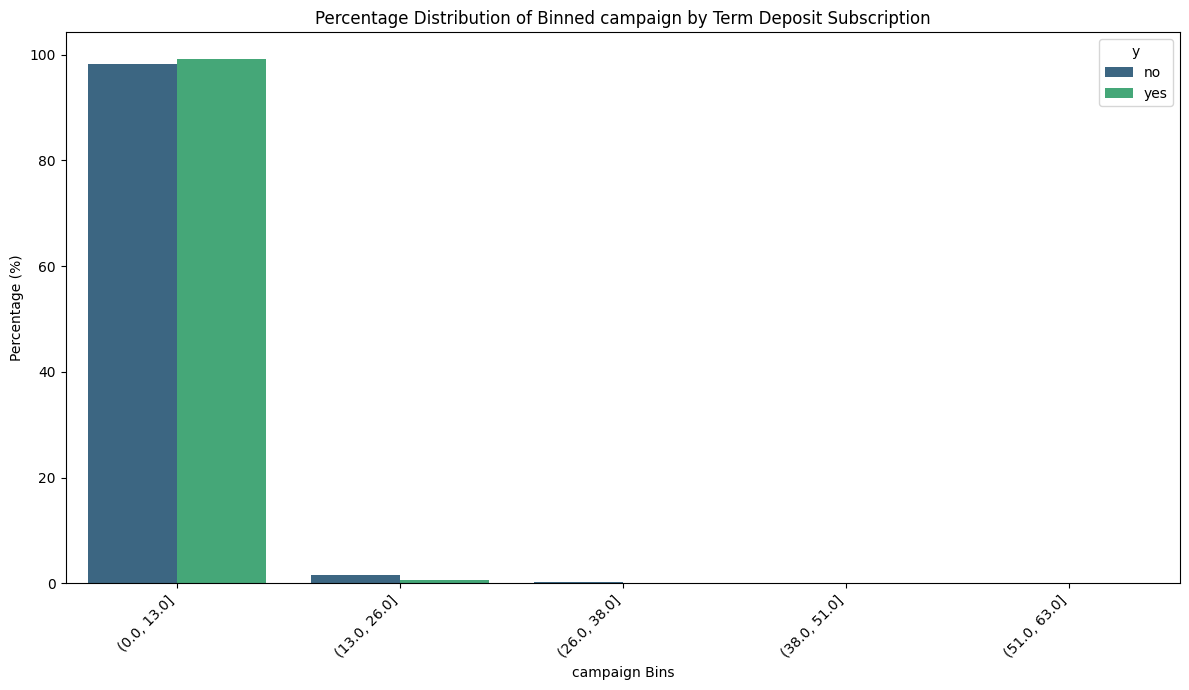

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Generating percentage distribution bar plots for binned numerical features vs. 'y' target variable:")

# Define the number of bins for each numerical column. Adjust as needed.
bin_counts = {
    'age': 5,
    'balance': 5,
    'day': 5, # You can adjust the number of bins
    'duration': 5,
    'campaign': 5
}

for col in numerical_cols:
    plt.figure(figsize=(12, 7))

    # Bin the numerical column. `cut` creates categorical bins.
    # `precision=0` rounds the bin edges for cleaner labels.
    # `include_lowest=True` ensures the lowest value is included.
    df_binned = df.copy()
    df_binned[f'{col}_binned'] = pd.cut(df[col], bins=bin_counts.get(col, 5), precision=0, include_lowest=True)

    # Calculate percentages within each 'y' category for the binned column
    # normalize='columns' calculates percentage relative to the sum of each 'y' column (y='no' vs y='yes')
    percentage_df = pd.crosstab(df_binned[f'{col}_binned'], df_binned['y'], normalize='columns') * 100

    # Melt the DataFrame for easier plotting with seaborn.barplot
    percentage_df_melted = percentage_df.reset_index().melt(id_vars=f'{col}_binned', var_name='y', value_name='percentage')

    sns.barplot(data=percentage_df_melted, x=f'{col}_binned', y='percentage', hue='y', palette='viridis')
    plt.title(f'Percentage Distribution of Binned {col} by Term Deposit Subscription')
    plt.xlabel(f'{col} Bins')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Generating grouped box plots for numerical features vs. 'y' target variable:


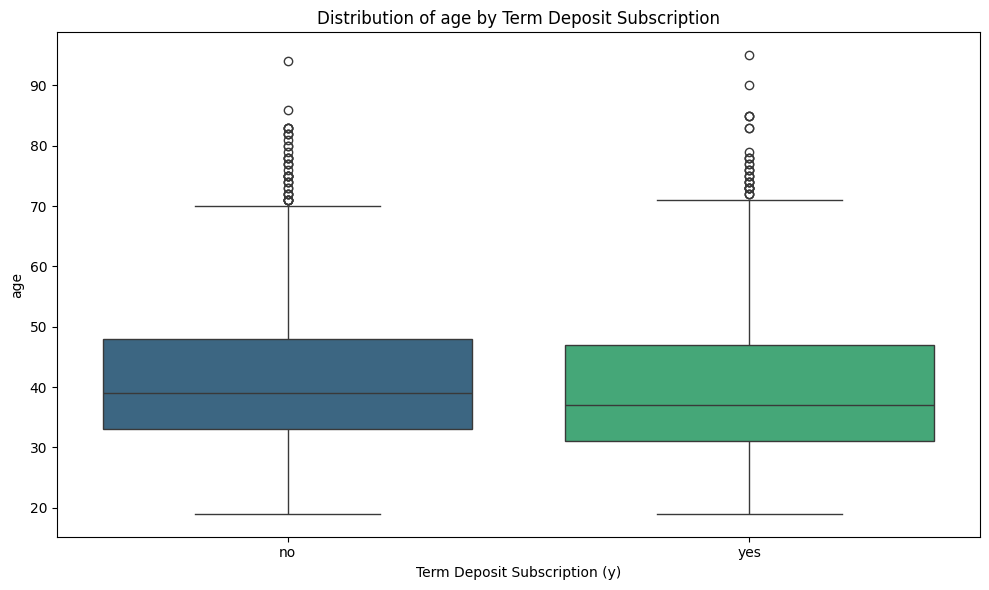

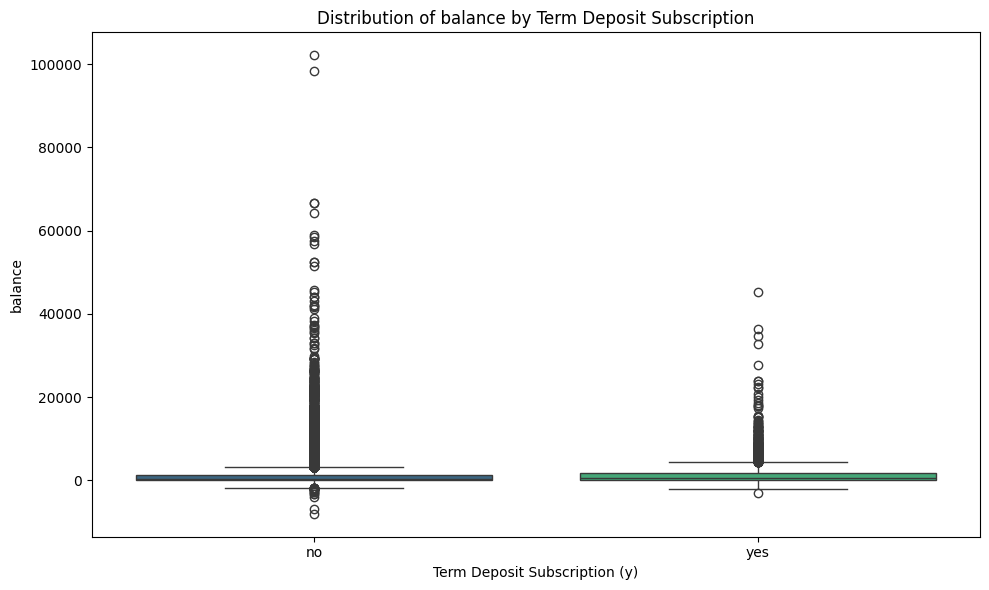

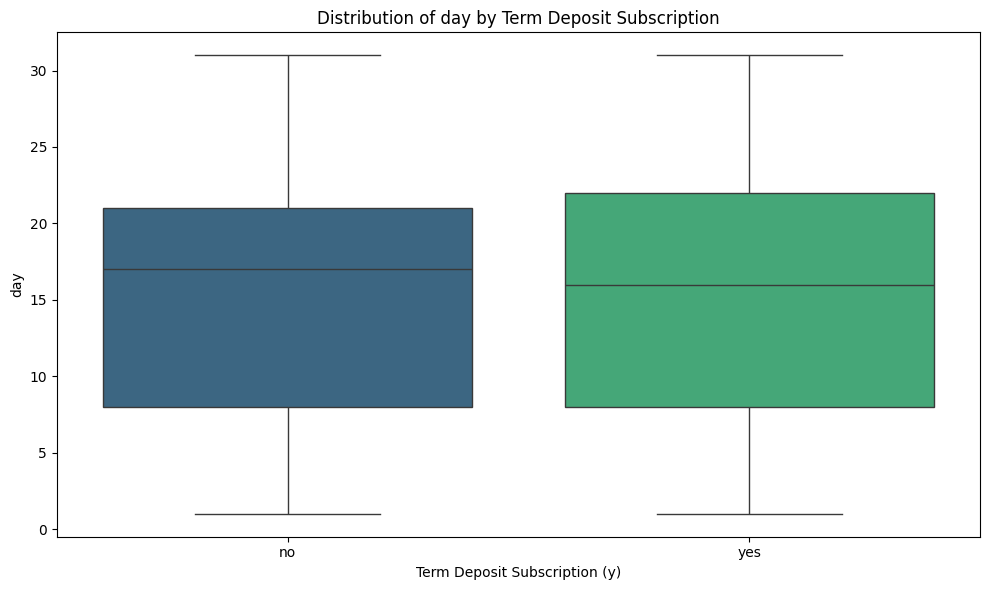

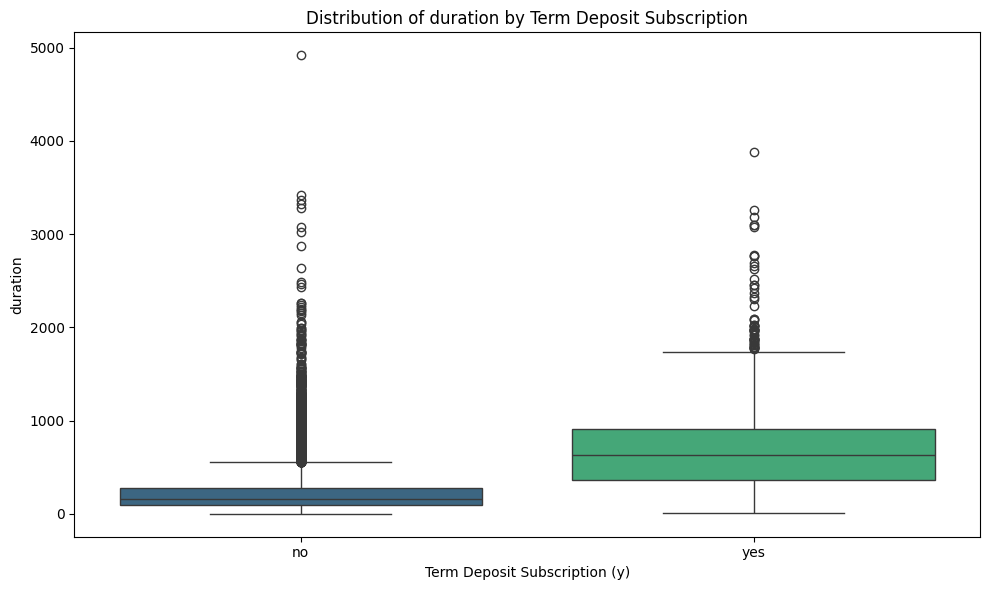

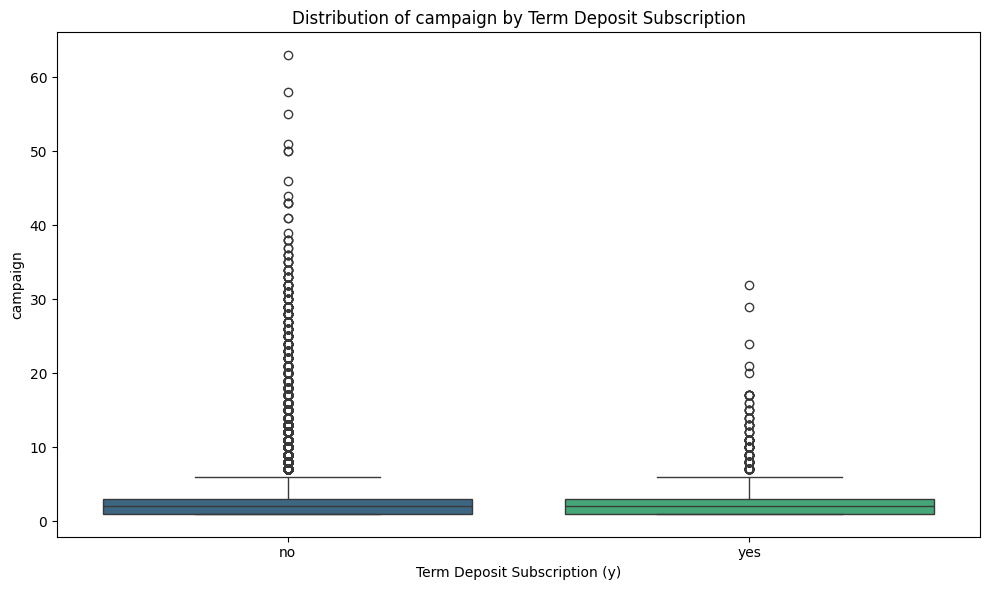

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identify numerical columns, excluding 'day' as it is cyclic and less directly comparable with box plots here
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# It's generally good practice to exclude 'day' from standard numerical analysis like this if it's treated as a cyclical feature.
# However, for the purpose of comparing distribution by 'y', it can still provide insights. Let's include all numerical for now.

print("Generating grouped box plots for numerical features vs. 'y' target variable:")

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x='y', y=col, hue='y', palette='viridis', legend=False)
    plt.title(f'Distribution of {col} by Term Deposit Subscription')
    plt.xlabel('Term Deposit Subscription (y)')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Generating grouped violin plots for numerical features vs. 'y' target variable with log transformation where appropriate:
  'age' column transformed using log(1+x).


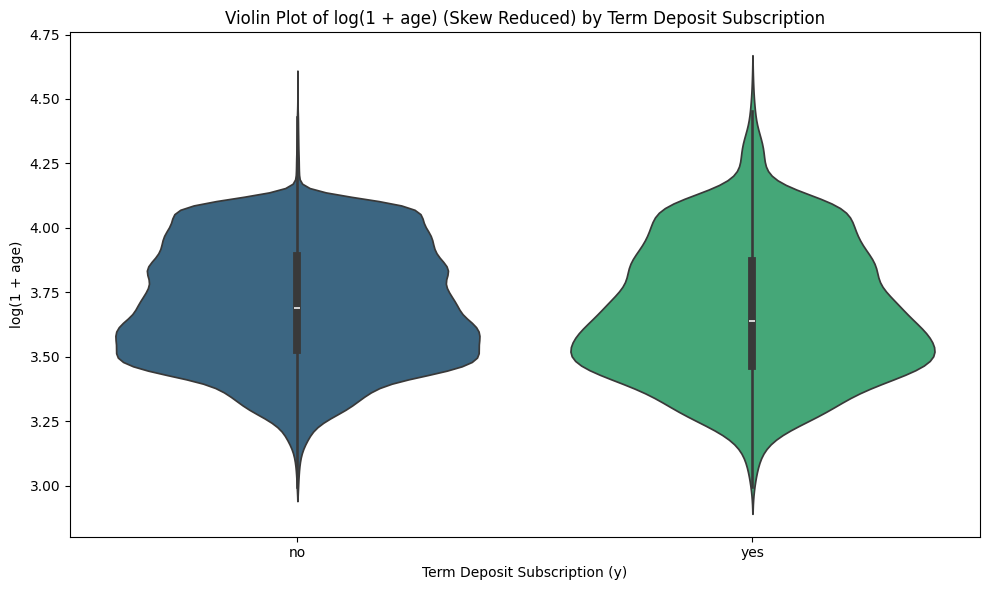

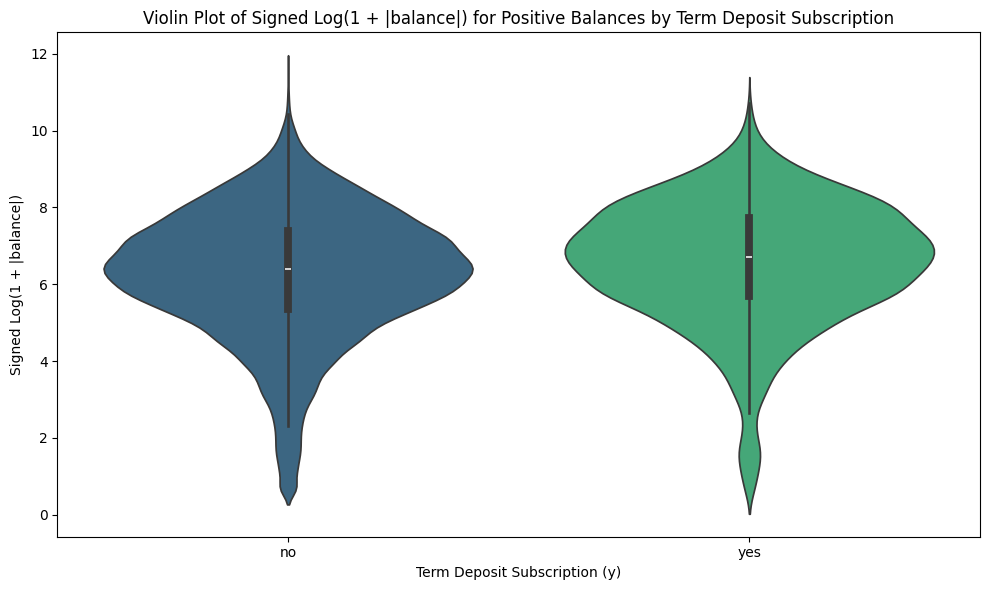

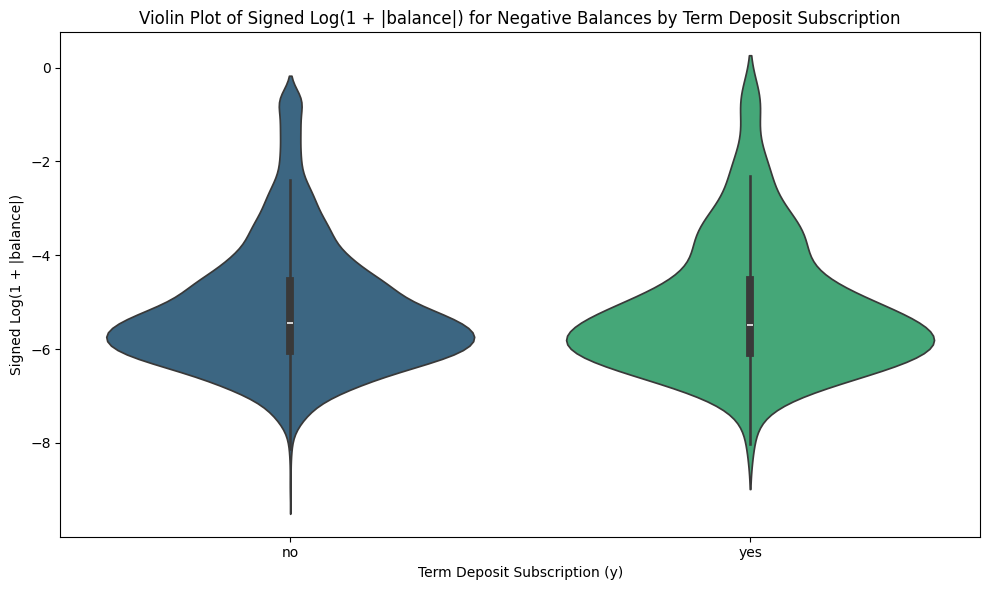

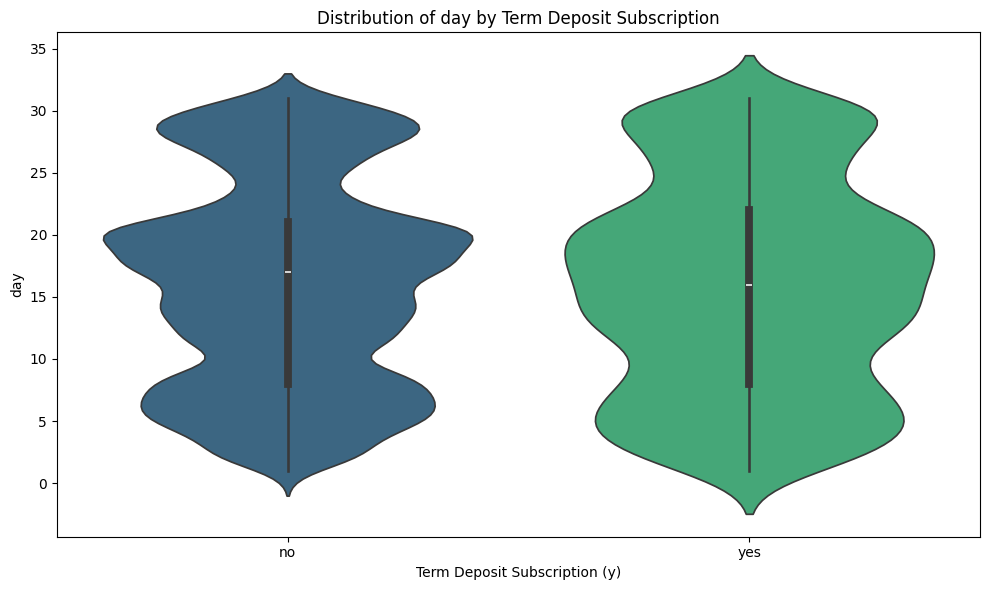

  'duration' column transformed using log(1+x).


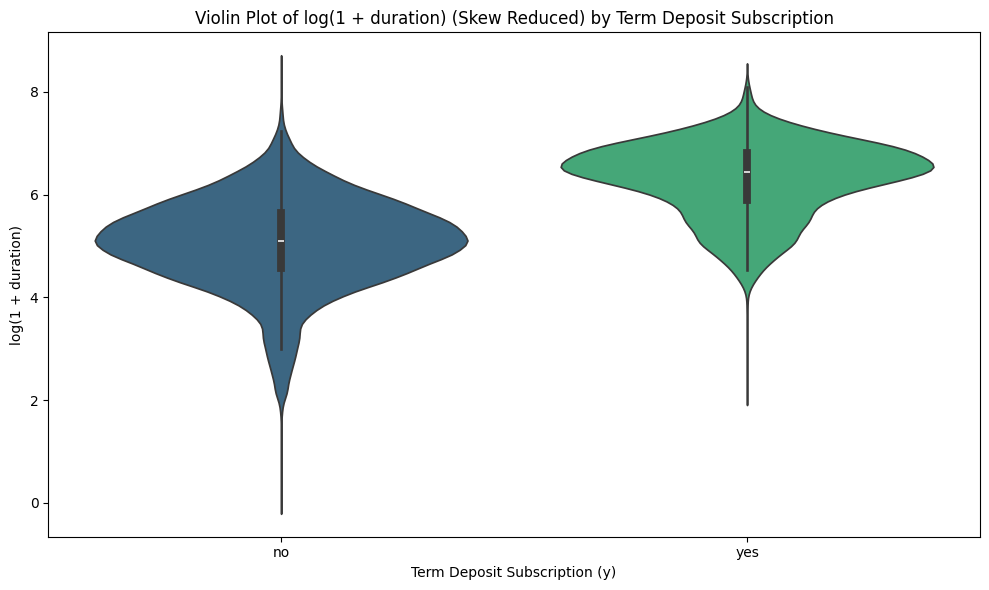

  'campaign' column transformed using log(1+x).


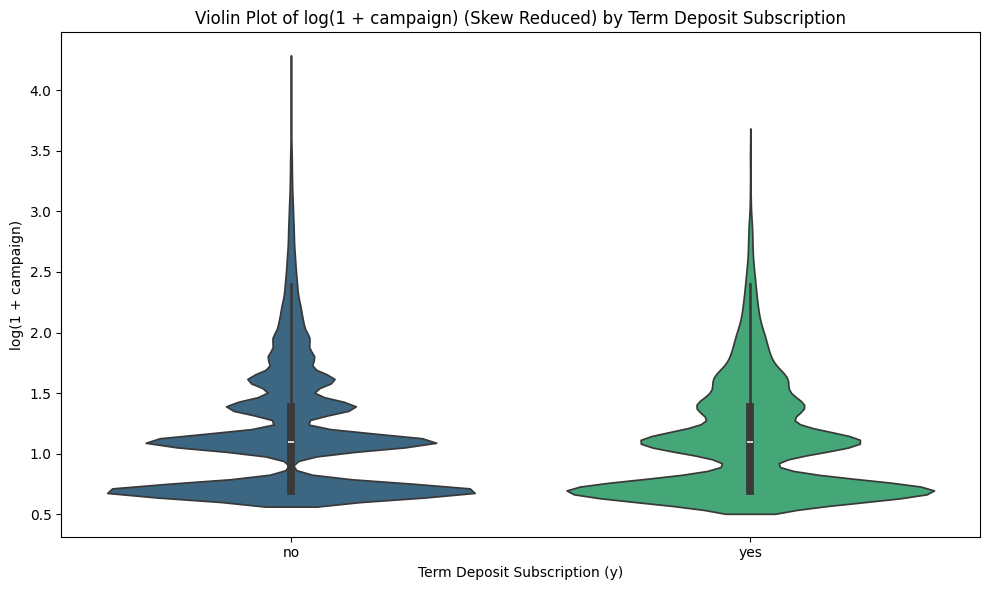

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Define a signed log transformation function
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

print("Generating grouped violin plots for numerical features vs. 'y' target variable with log transformation where appropriate:")

# Create a copy of the DataFrame to add transformed columns for plotting
df_plotting = df.copy()

for col in df.select_dtypes(include=np.number).columns.tolist():
    plt.figure(figsize=(10, 6))

    if col == 'balance':
        # Apply signed log transformation to balance
        df_plotting['signed_log_balance'] = signed_log1p(df_plotting['balance'])

        # Plot for positive balances
        df_pos_balance = df_plotting[df_plotting['balance'] > 0].copy()
        if not df_pos_balance.empty:
            sns.violinplot(data=df_pos_balance, x='y', y='signed_log_balance', hue='y', palette='viridis', legend=False)
            plt.title(f'Violin Plot of Signed Log(1 + |{col}|) for Positive Balances by Term Deposit Subscription')
            plt.xlabel('Term Deposit Subscription (y)')
            plt.ylabel(f'Signed Log(1 + |{col}|)')
            plt.tight_layout()
            plt.show()
        else:
            print(f"  No positive '{col}' values to plot after transformation for y='yes' vs y='no'.")

        # Plot for negative balances
        df_neg_balance = df_plotting[df_plotting['balance'] < 0].copy()
        if not df_neg_balance.empty:
            plt.figure(figsize=(10, 6))
            sns.violinplot(data=df_neg_balance, x='y', y='signed_log_balance', hue='y', palette='viridis', legend=False)
            plt.title(f'Violin Plot of Signed Log(1 + |{col}|) for Negative Balances by Term Deposit Subscription')
            plt.xlabel('Term Deposit Subscription (y)')
            plt.ylabel(f'Signed Log(1 + |{col}|)')
            plt.tight_layout()
            plt.show()
        else:
            print(f"  No negative '{col}' values to plot after transformation for y='yes' vs y='no'.")

    elif col in ['age', 'duration', 'campaign']:
        # Apply log(1+x) transformation for positively skewed, non-negative data
        df_plotting[f'log_{col}'] = np.log1p(df_plotting[col])
        sns.violinplot(data=df_plotting, x='y', y=f'log_{col}', hue='y', palette='viridis', legend=False)
        plt.title(f'Violin Plot of log(1 + {col}) (Skew Reduced) by Term Deposit Subscription')
        plt.xlabel('Term Deposit Subscription (y)')
        plt.ylabel(f'log(1 + {col})')
        print(f"  '{col}' column transformed using log(1+x).")
        plt.tight_layout()
        plt.show()

    else:
        # For 'day' or any other numerical column not needing special transformation
        sns.violinplot(data=df_plotting, x='y', y=col, hue='y', palette='viridis', legend=False)
        plt.title(f'Distribution of {col} by Term Deposit Subscription')
        plt.xlabel('Term Deposit Subscription (y)')
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()

for ppl with negative balances, the interests on the loans could outweigh the interests gained from the term deposit

# Multivariate analysis

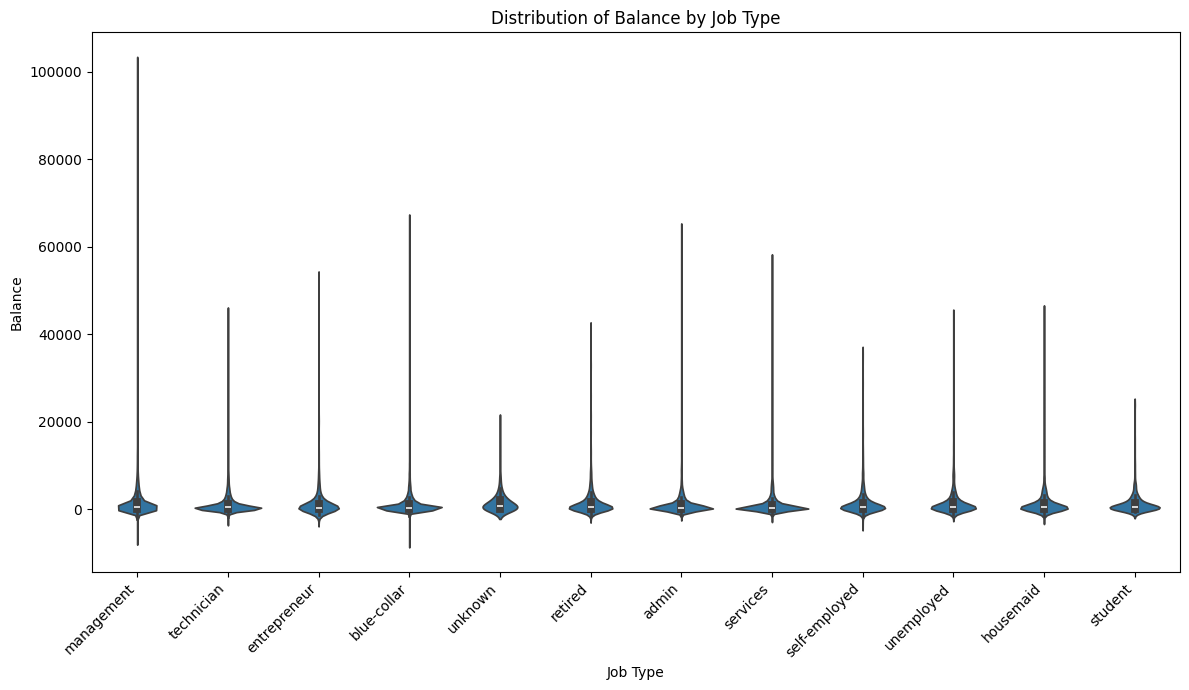

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.violinplot(x='job', y='balance', data=df)
plt.title('Distribution of Balance by Job Type')
plt.xlabel('Job Type')
plt.ylabel('Balance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

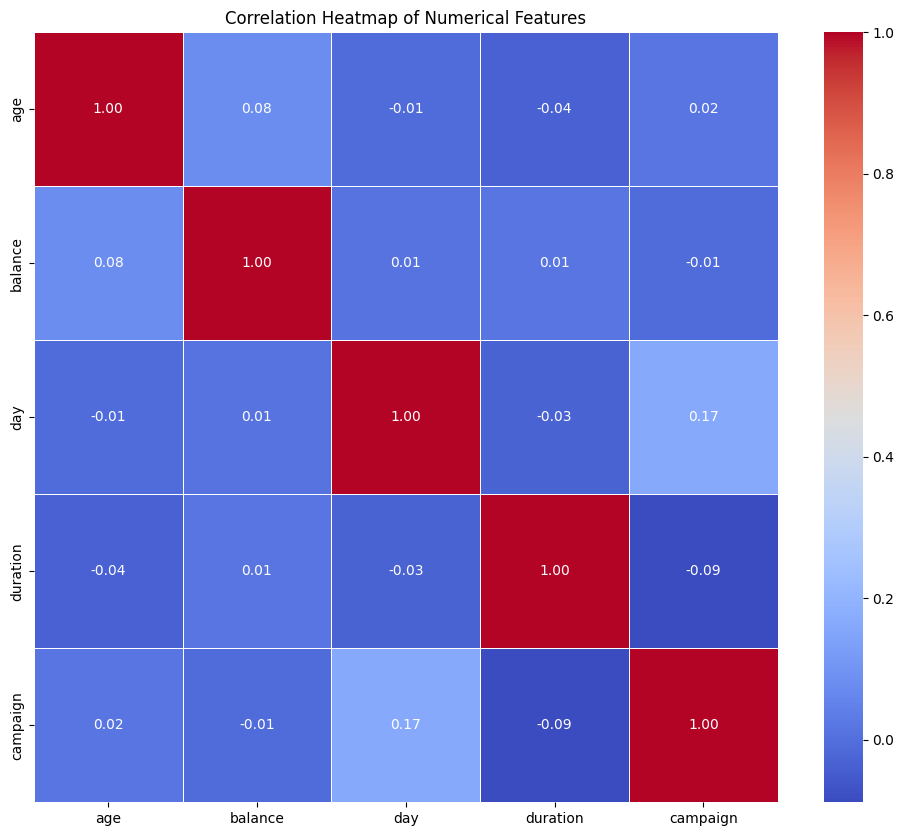

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.drop('y', errors='ignore')

print("Categorical columns (excluding 'y'):")
print(categorical_cols)

Categorical columns (excluding 'y'):
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month'],
      dtype='object')


Generating grouped bar plots for 'job' and 'marital' vs. 'y' target variable:


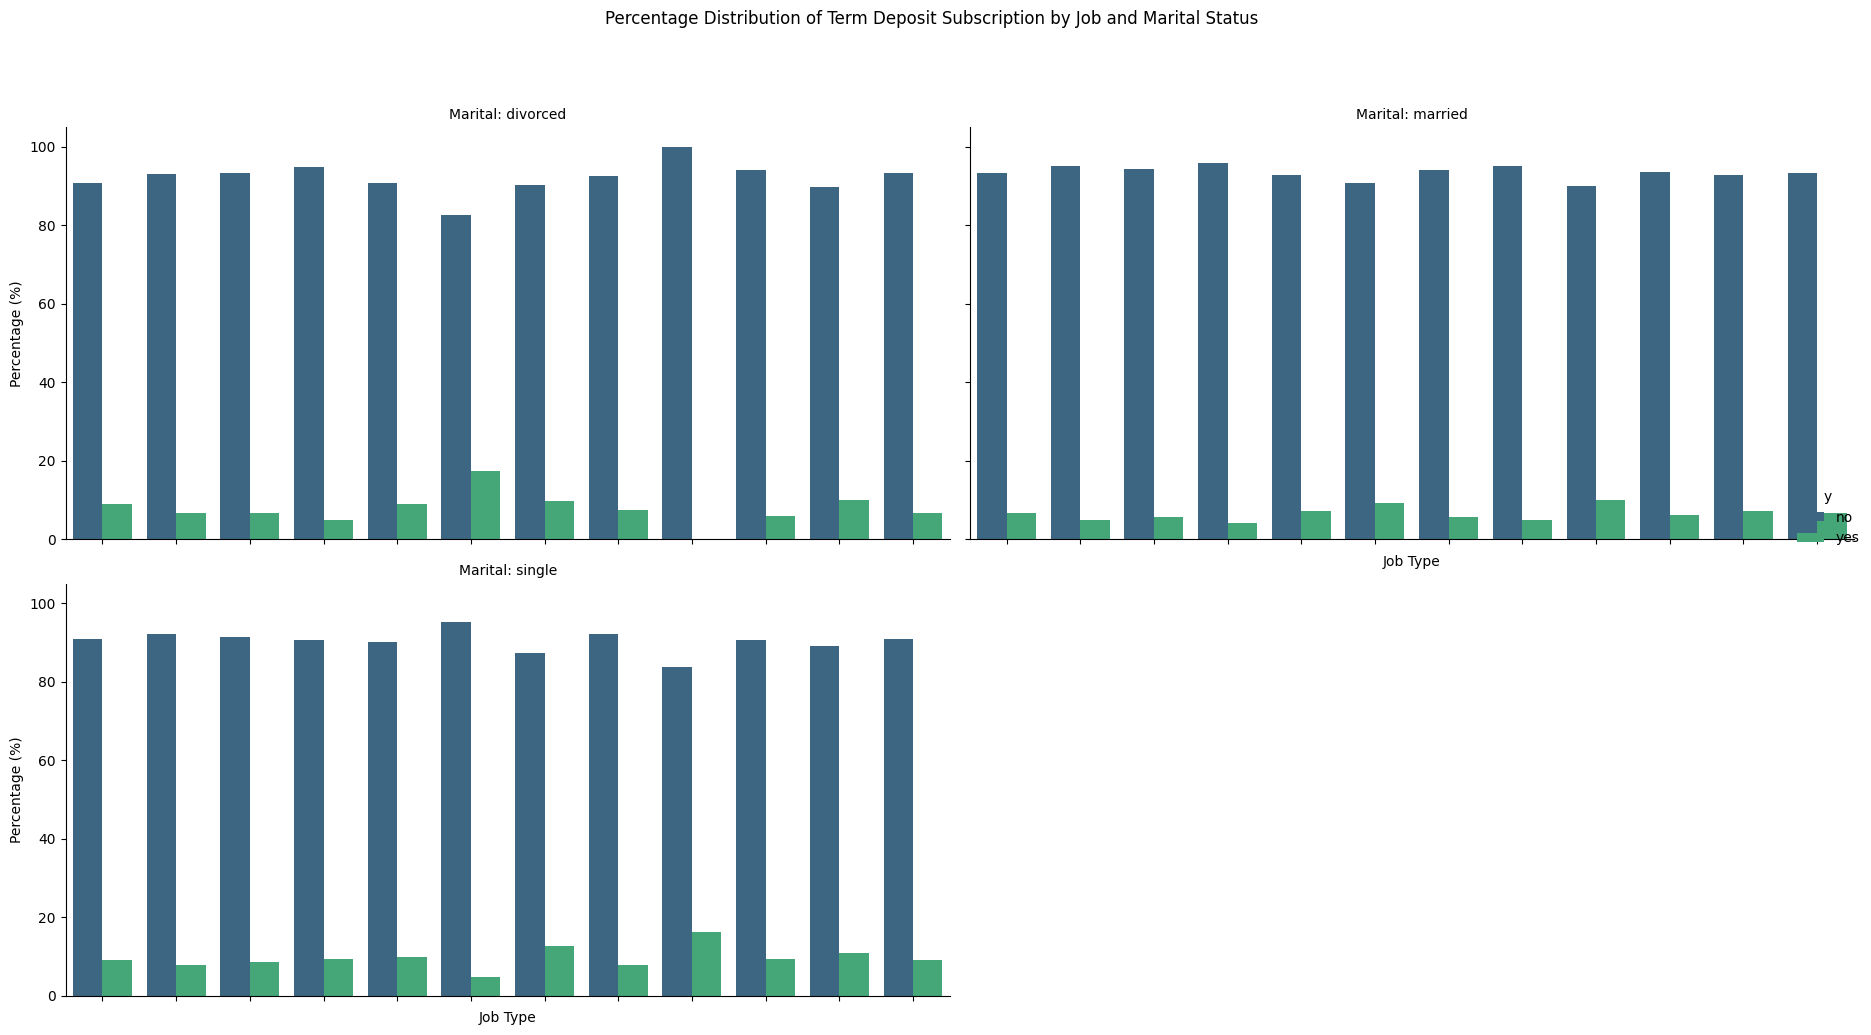

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Generating grouped bar plots for 'job' and 'marital' vs. 'y' target variable:")

# Create a cross-tabulation of 'job', 'marital', and 'y'
crosstab_job_marital = pd.crosstab([df['job'], df['marital']], df['y'], normalize='index') * 100

# Reset index to make 'job' and 'marital' columns for plotting
crosstab_job_marital_reset = crosstab_job_marital.reset_index()

# Melt the DataFrame for easier plotting with seaborn
crosstab_job_marital_melted = crosstab_job_marital_reset.melt(id_vars=['job', 'marital'], var_name='y', value_name='percentage')

# Use sns.catplot for faceting by 'marital'
g = sns.catplot(
    data=crosstab_job_marital_melted,
    x='job',
    y='percentage',
    hue='y',
    col='marital',
    col_wrap=2, # Wrap columns after 2 plots
    kind='bar', # Specify the plot type as bar
    palette='viridis',
    height=5, # Height of each facet
    aspect=1.8, # Aspect ratio of each facet
    errorbar=None, # Replaces ci=None
    sharey=True # Share y-axis across facets
)

g.set_axis_labels("Job Type", "Percentage (%)")
g.set_titles("Marital: {col_name}")
g.set_xticklabels(rotation=45, ha='right')
g.fig.suptitle('Percentage Distribution of Term Deposit Subscription by Job and Marital Status', y=1.03) # Adjust suptitle position for catplot figure
g.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

Generating grouped bar plots for 'education' and 'housing' vs. 'y' target variable:


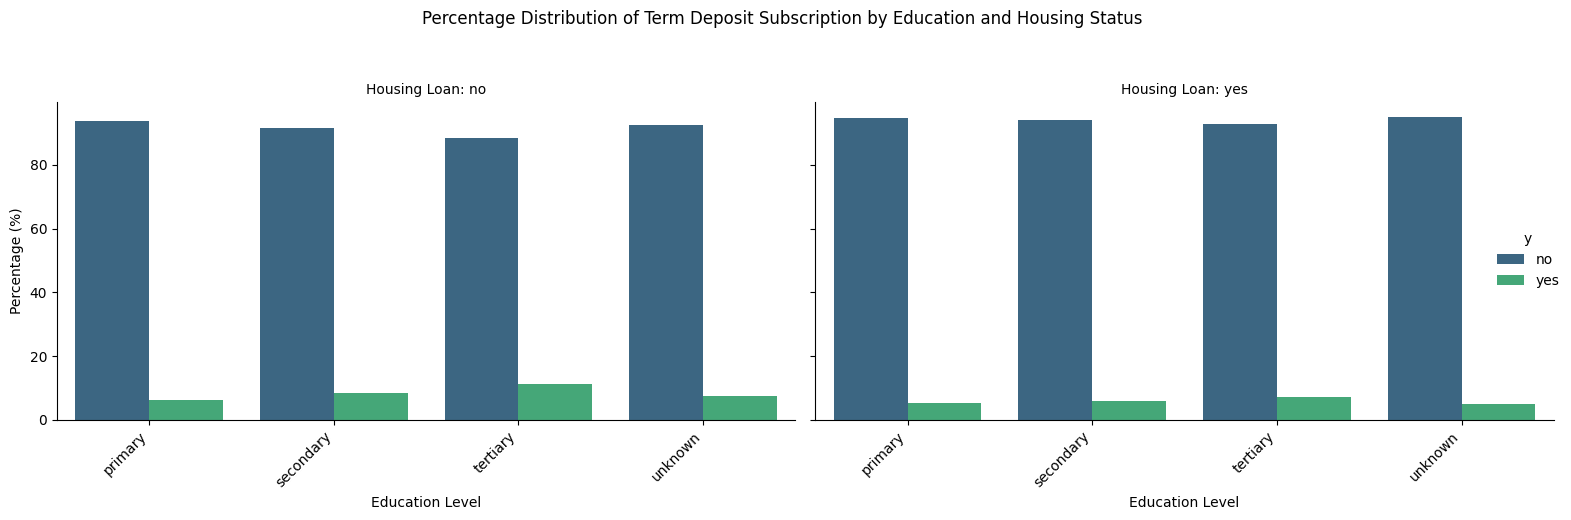

In [ ]:
print("Generating grouped bar plots for 'education' and 'housing' vs. 'y' target variable:")

# Create a cross-tabulation of 'education', 'housing', and 'y'
crosstab_education_housing = pd.crosstab([df['education'], df['housing']], df['y'], normalize='index') * 100

# Reset index to make 'education' and 'housing' columns for plotting
crosstab_education_housing_reset = crosstab_education_housing.reset_index()

# Melt the DataFrame for easier plotting with seaborn
crosstab_education_housing_melted = crosstab_education_housing_reset.melt(id_vars=['education', 'housing'], var_name='y', value_name='percentage')

# Use sns.catplot for faceting by 'housing'
g = sns.catplot(
    data=crosstab_education_housing_melted,
    x='education',
    y='percentage',
    hue='y',
    col='housing',
    col_wrap=2, # Wrap columns after 2 plots
    kind='bar', # Specify the plot type as bar
    palette='viridis',
    height=5, # Height of each facet
    aspect=1.5, # Aspect ratio of each facet
    errorbar=None, # Replaces ci=None
    sharey=True # Share y-axis across facets
)

g.set_axis_labels("Education Level", "Percentage (%)")
g.set_titles("Housing Loan: {col_name}")
g.set_xticklabels(rotation=45, ha='right')
g.fig.suptitle('Percentage Distribution of Term Deposit Subscription by Education and Housing Status', y=1.03) # Adjust suptitle position for catplot figure
g.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

# Conclusion

The dataset is rich, comprising 40,000 entries and 14 features. There is a significant class imbalance in the target variable 'y' (term deposit subscription): only 7.24% of the customers responded 'yes', compared to the rest of the customers (92.76%) who responded 'no'.

Numerical features such as 'balance', 'duration', and 'campaign' exhibit skewness. Log transformations were applied during univariate analysis to reduce this skew, but the raw distributions indicate the presence of outliers and a non-normal distribution.

Several categorical features, including 'job', 'education', and 'contact', contain 'unknown' labels. While the percentages of 'unknown' vary, their presence suggests either missing data or a distinct category that needs careful consideration during feature engineering.

While outliers exist, I've chosen to include them in the customer segmentation to capture the full range of behaviors. It would bring a more comprehensive view of how different clusters of customers are distributed.